<a href="https://colab.research.google.com/github/deep1185/ga-learner-dsmp-repo/blob/master/retail_EDA_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter

In [2]:
!gdown 1gggqFLKcFH64D6xzXMef1AfRVz0Zcw3a
df=pd.read_csv('online_retail.csv')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1gggqFLKcFH64D6xzXMef1AfRVz0Zcw3a
To: /content/online_retail.csv
100% 48.6M/48.6M [00:01<00:00, 29.9MB/s]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#null check
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [4]:
#drop nulls in description column
df_new = df.dropna(subset=['Description'])

In [5]:
#descriptive stats check
df_new.describe()

# Here we can see quantity has some negative values, we will drop such entries

,Quantity,UnitPrice,CustomerID
count,540455.000000,540455.000000,406829.000000
mean,9.603129,4.623519,15287.690570
std,218.007598,96.889628,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
#remove negetive qty
df_new = df_new[df_new.Quantity > 0]

In [7]:
#descriptive stats check
df_new.describe()

,Quantity,UnitPrice,CustomerID
count,530693.000000,530693.000000,397924.000000
mean,10.605819,3.861599,15294.315171
std,156.637853,41.833162,1713.169877
min,1.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


Based on Worldwide Popularity

In [8]:
#pivoting to get top products by quantity
global_popularity=df_new.pivot_table(
    index=['StockCode','Description'],
    values='Quantity',
    aggfunc='sum').sort_values(
    by='Quantity', ascending=False)
print('Top 10 popular items globally....')
global_popularity.head(10)

Top 10 popular items globally....


,,Quantity
StockCode,Description,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
85099B,JUMBO BAG RED RETROSPOT,48478
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37603
22197,POPCORN HOLDER,36761
84879,ASSORTED COLOUR BIRD ORNAMENT,36461
21212,PACK OF 72 RETROSPOT CAKE CASES,36419
23084,RABBIT NIGHT LIGHT,30788


In [9]:
def random_colours(number_of_colors):
    '''
    Simple function for random colours generation.
    Input:
        number_of_colors - integer value indicating the number of colours which are going to be generated.
    Output:
        Color in the following format: ['#E86DA4'] .
    '''
    colors = []
    for i in range(number_of_colors):
        colors.append("#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)]))
    return colors

<ipython-input-10-c9b063fc077f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity', data=global_popularity.head(10), palette=random_colours(10))


Text(0, 0.5, 'Item')

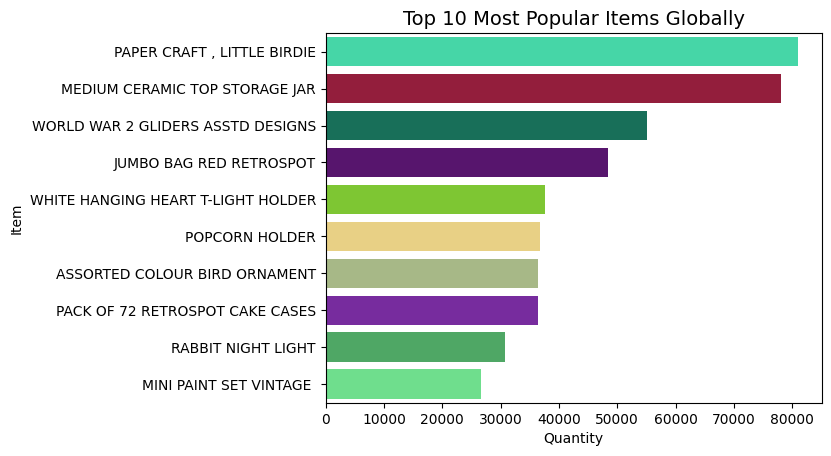

In [10]:
#viz - top products by quantity
import random
global_popularity.reset_index(inplace=True)
sns.barplot(y='Description', x='Quantity', data=global_popularity.head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items Globally', fontsize=14)
plt.ylabel('Item')

Bought by Most Customers

In [11]:
# Creating a pivot table that displays the sum of unique Customers who bought particular item, instead of regular groupby function
bought_by_most_customers = df_new.pivot_table(index=['StockCode','Description'], values='CustomerID', aggfunc=lambda x: len(x.unique())).sort_values(by='CustomerID', ascending=False)

<ipython-input-12-9052a1948025>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='CustomerID', data=bought_by_most_customers.head(10), palette=random_colours(10))


Text(0, 0.5, 'Item')

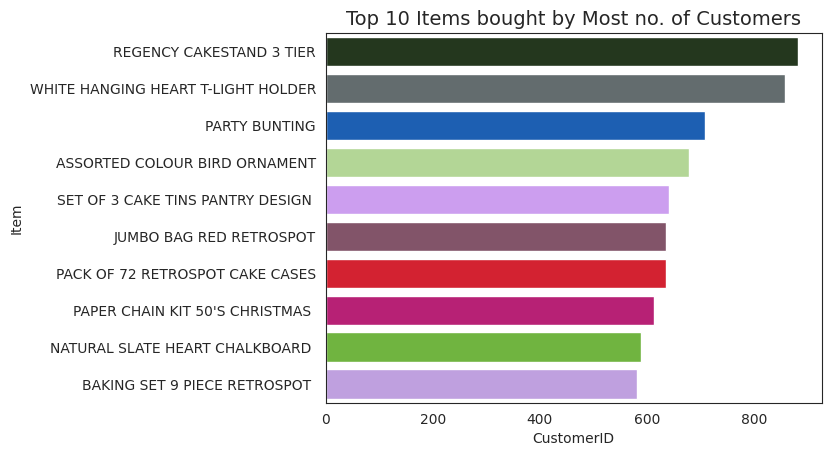

In [12]:
bought_by_most_customers.reset_index(inplace=True)
sns.set_style('white')

# Creating a bar plot of Description ( or the item ) on the Y axis and the sum of unique Customers on the X axis
# We are plotting only the 10 most bought items
sns.barplot(y='Description', x='CustomerID', data=bought_by_most_customers.head(10), palette=random_colours(10))

# Giving suitable title to the plot
plt.title('Top 10 Items bought by Most no. of Customers', fontsize=14)

plt.ylabel('Item')

Most Frequently Ordered Items

In [13]:
# Preparing data for wordcloud
df1 = df_new.copy()
df1['items'] = df1['Description'].str.replace(' ', '_')

Downloading...
From: https://drive.google.com/uc?id=1nZ1xm2p-9SpQLxZjzwzspHFvIDCncZFm
To: /content/comment.png
100% 141k/141k [00:00<00:00, 66.0MB/s]


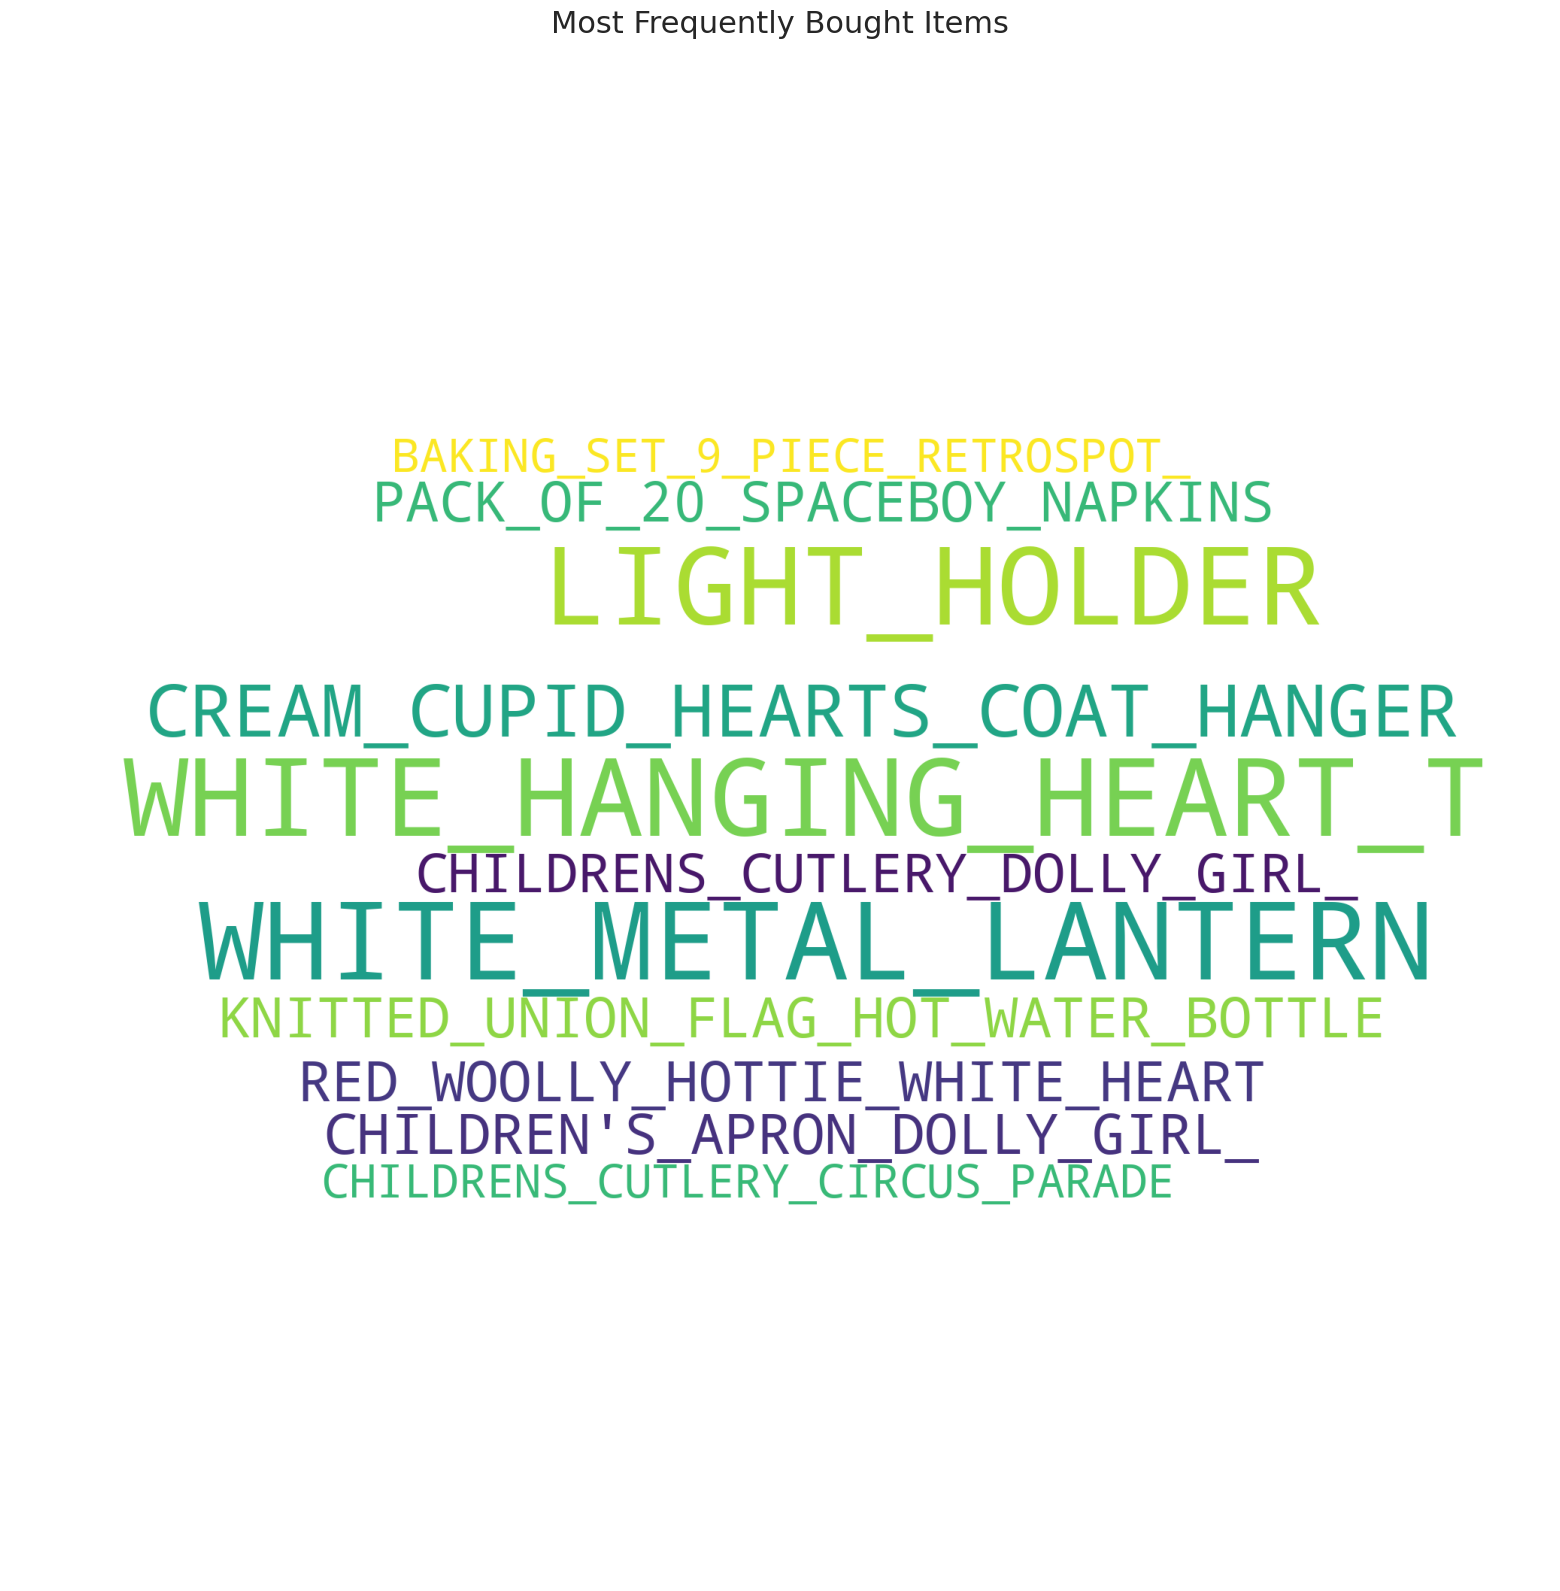

<Figure size 1000x1000 with 0 Axes>

In [14]:
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
!gdown 1nZ1xm2p-9SpQLxZjzwzspHFvIDCncZFm
background = np.array(Image.open('comment.png'))
plt.rcParams['figure.figsize'] = (20, 20)
# word_string=' '.join(df['Findings'].astype("str").values)
STOPWORDS.update(['Name',"dtype","items","object","Length"])
wordcloud = WordCloud(stopwords=STOPWORDS,
                      collocations=False,
                       width = 1200,  height = 1200,
                      background_color ='white',
                      min_font_size = 0.001,
                      mask=background).generate(str(df1['items']))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Most Frequently Bought Items',fontsize = 22)
plt.subplots(figsize=(10,10))
plt.clf()
plt.show()

##Top 10 Firsts in a List
These are list of Items which are firstly picked most of the times by customers when they have bought multiple products every time

In [15]:
# Storing all the unique invoice numbers into a list invoices
invoices = list(df1['InvoiceNo'].unique())
len(invoices)

20136

In [16]:
# Creating empty list first_choices
first_choices = []

# looping into list of unique invoice numbers
for i in invoices:

    # the first item (index = 0) of every invoice is the first purchase
    # extracting the item name for the first purchase
    first_purchase = df1[df1['InvoiceNo']==i]['items'].reset_index(drop=True)[0]

    # Appending the first purchase name into first choices list
    first_choices.append(first_purchase)

In [17]:
first_choices[:5]

['WHITE_HANGING_HEART_T-LIGHT_HOLDER',
 'HAND_WARMER_UNION_JACK',
 'ASSORTED_COLOUR_BIRD_ORNAMENT',
 'JAM_MAKING_SET_WITH_JARS',
 'BATH_BUILDING_BLOCK_WORD']

In [18]:
# Using counter to count repeating first choices
count = Counter(first_choices)

In [19]:
# Storing the counter into a datafrane
df_first_choices = pd.DataFrame.from_dict(count, orient='index').reset_index()

# Rename columns as item and count
df_first_choices.rename(columns={'index':'item', 0:'count'},inplace=True)

# Sorting the df based on count
df_first_choices.sort_values(by='count',ascending=False)

,item,count
181,REGENCY_CAKESTAND_3_TIER,207
0,WHITE_HANGING_HEART_T-LIGHT_HOLDER,183
1794,RABBIT_NIGHT_LIGHT,156
271,Manual,142
221,POSTAGE,136
...,...,...
2734,MAGIC_SHEEP_WOOL_GROWING_FROM_PAPER,1
2733,"WHITE_TEA,COFFEE,SUGAR_JARS",1
2781,VINTAGE_ZINC_PLANTER__,1
2779,BLACK_SQUARE_TABLE_CLOCK,1


<ipython-input-20-dc4d1113b77c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='item', x='count', data=df_first_choices.sort_values(by='count',ascending=False).head(10), palette=random_colours(10))


Text(0, 0.5, 'Item')

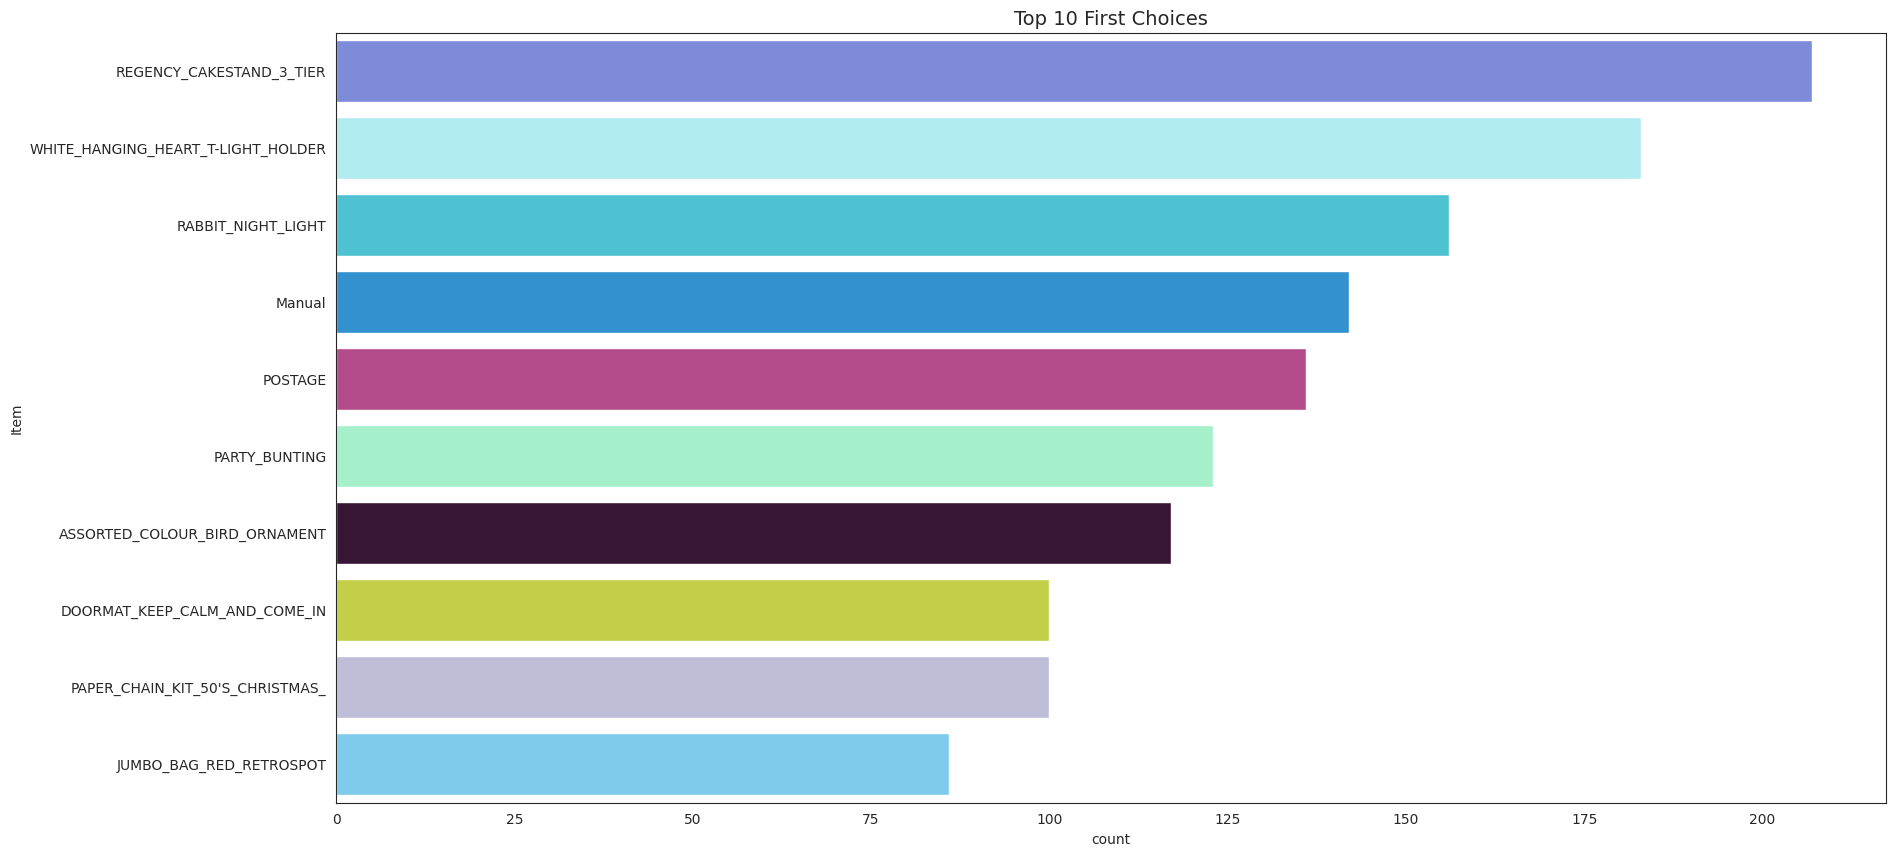

In [20]:
plt.subplots(figsize=(20,10))
sns.set_style('white')

# Creating a bar plot that displays Item name on the Y axis and Count on the X axis
sns.barplot(y='item', x='count', data=df_first_choices.sort_values(by='count',ascending=False).head(10), palette=random_colours(10))

# Giving suitable title to the plot
plt.title('Top 10 First Choices', fontsize=14)

plt.ylabel('Item')

​Based on Countrywise Popularity

In [21]:
#pivoting to get top products by quantity and country
countrywise=df_new.pivot_table(
    index=['Country','StockCode','Description'],
    values='Quantity',
    aggfunc='sum').reset_index()

In [22]:
countrywise['Country'].value_counts()

,count
Country,
United Kingdom,4300
EIRE,2018
Germany,1697
France,1565
Spain,1105
Switzerland,987
Netherlands,803
Belgium,786
Portugal,714


<ipython-input-24-5ded77efdbbc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',


Text(0, 0.5, 'Item')

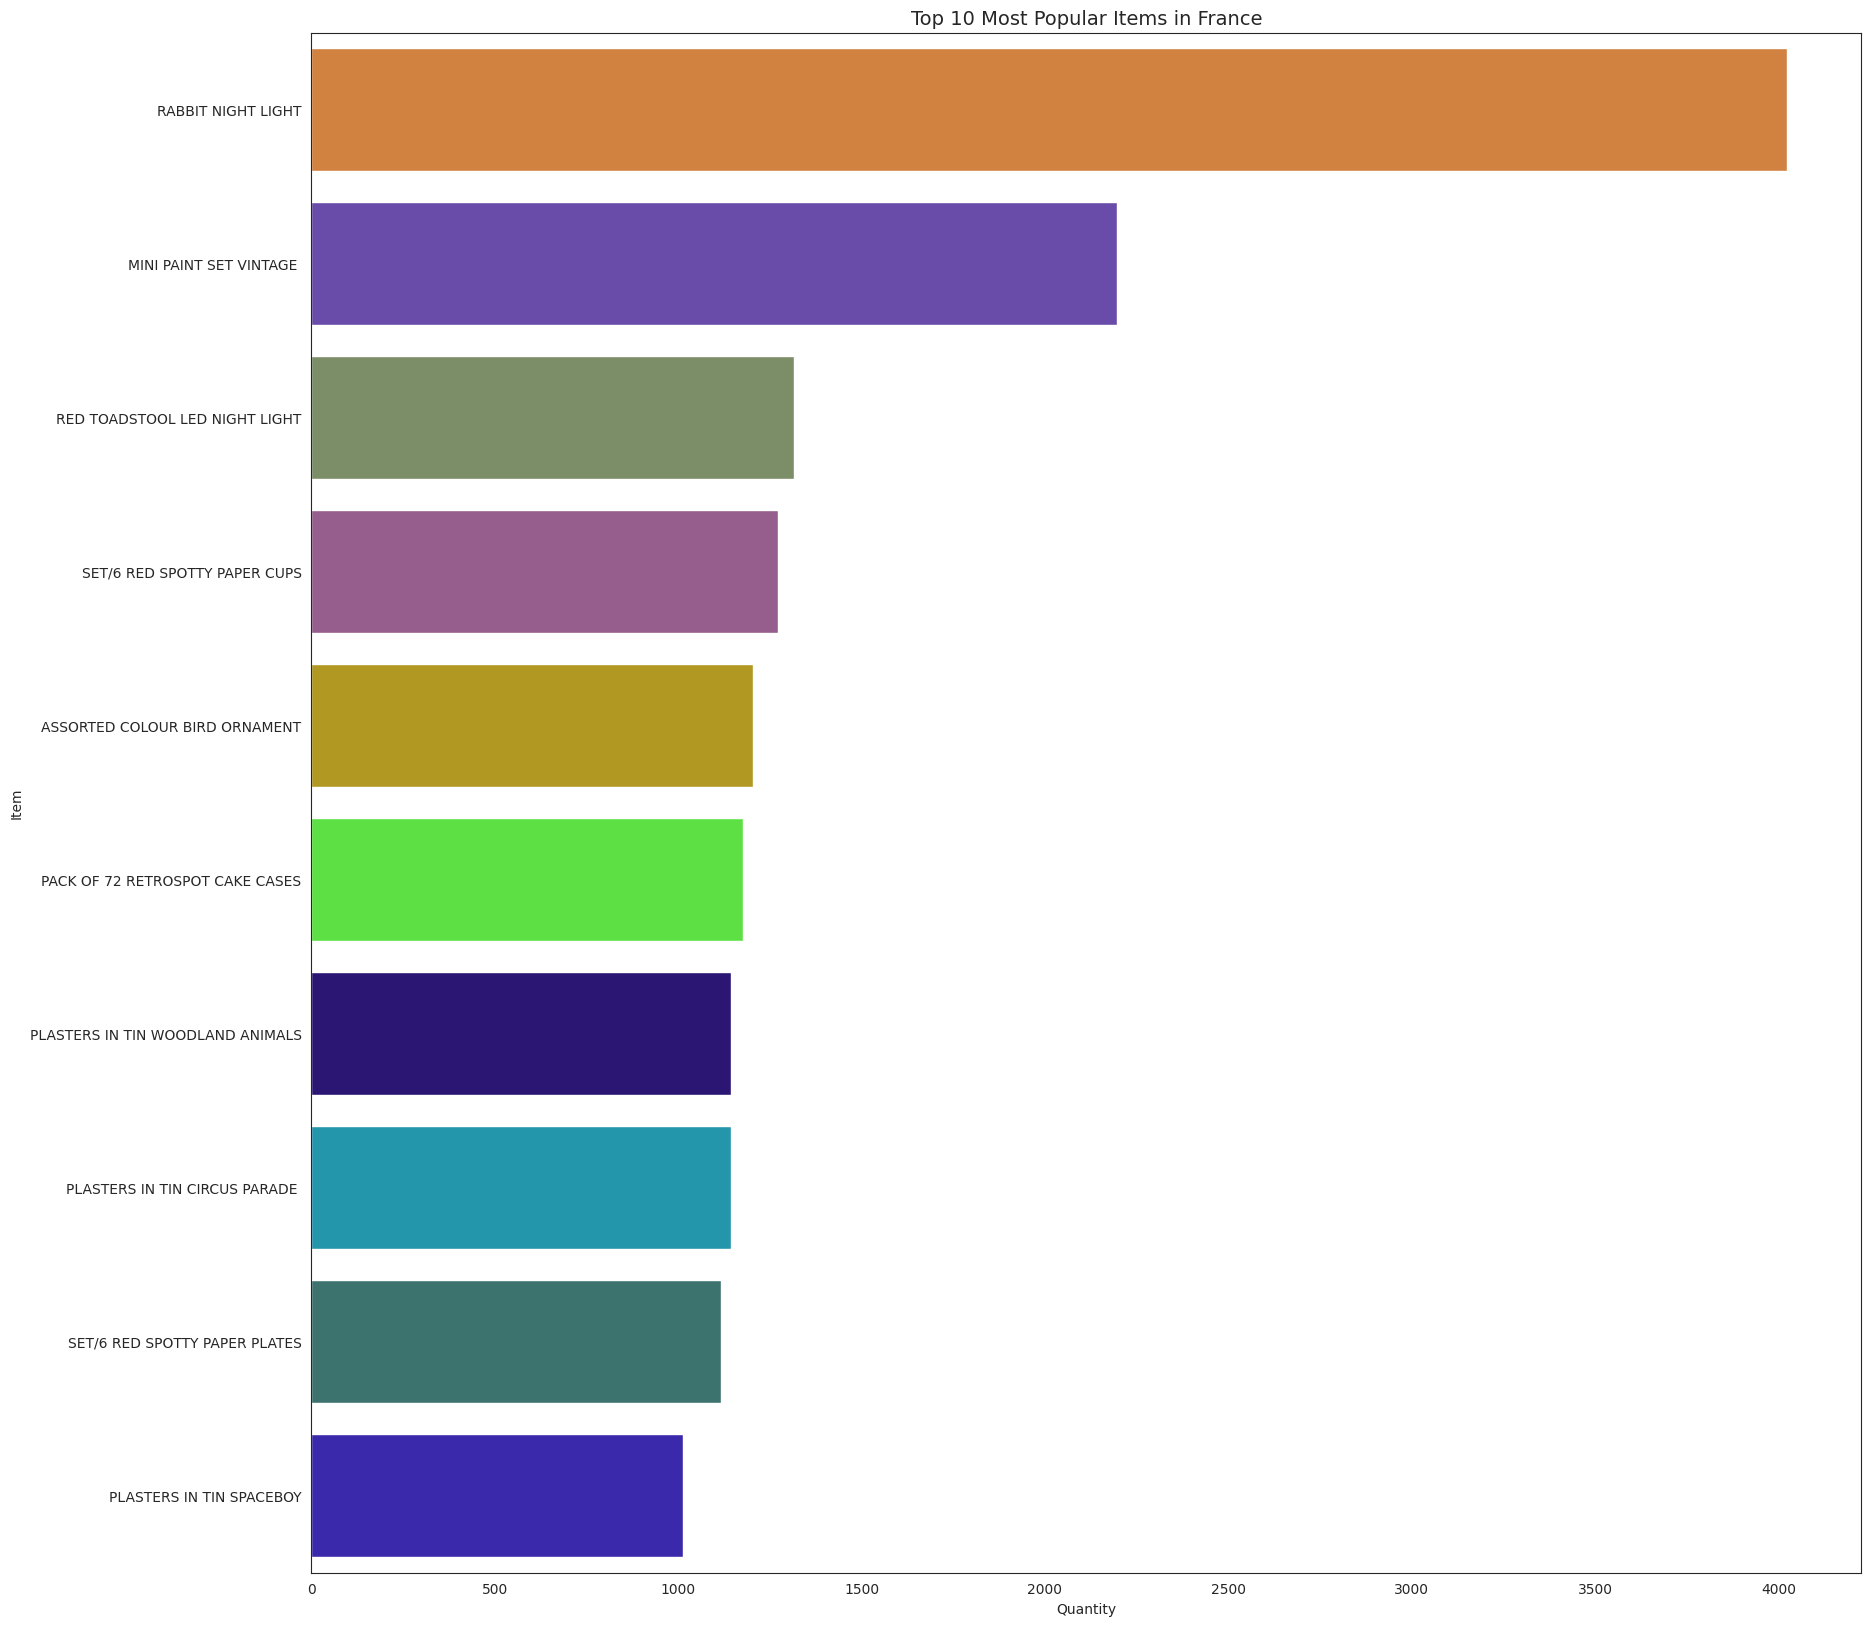

In [24]:
#Viz
sns.barplot(y='Description', x='Quantity',
            data=countrywise[countrywise['Country']=='France'].sort_values(
                by='Quantity', ascending=False).head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items in France', fontsize=14)
plt.ylabel('Item')

<ipython-input-25-40531a871c59>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',


Text(0, 0.5, 'Item')

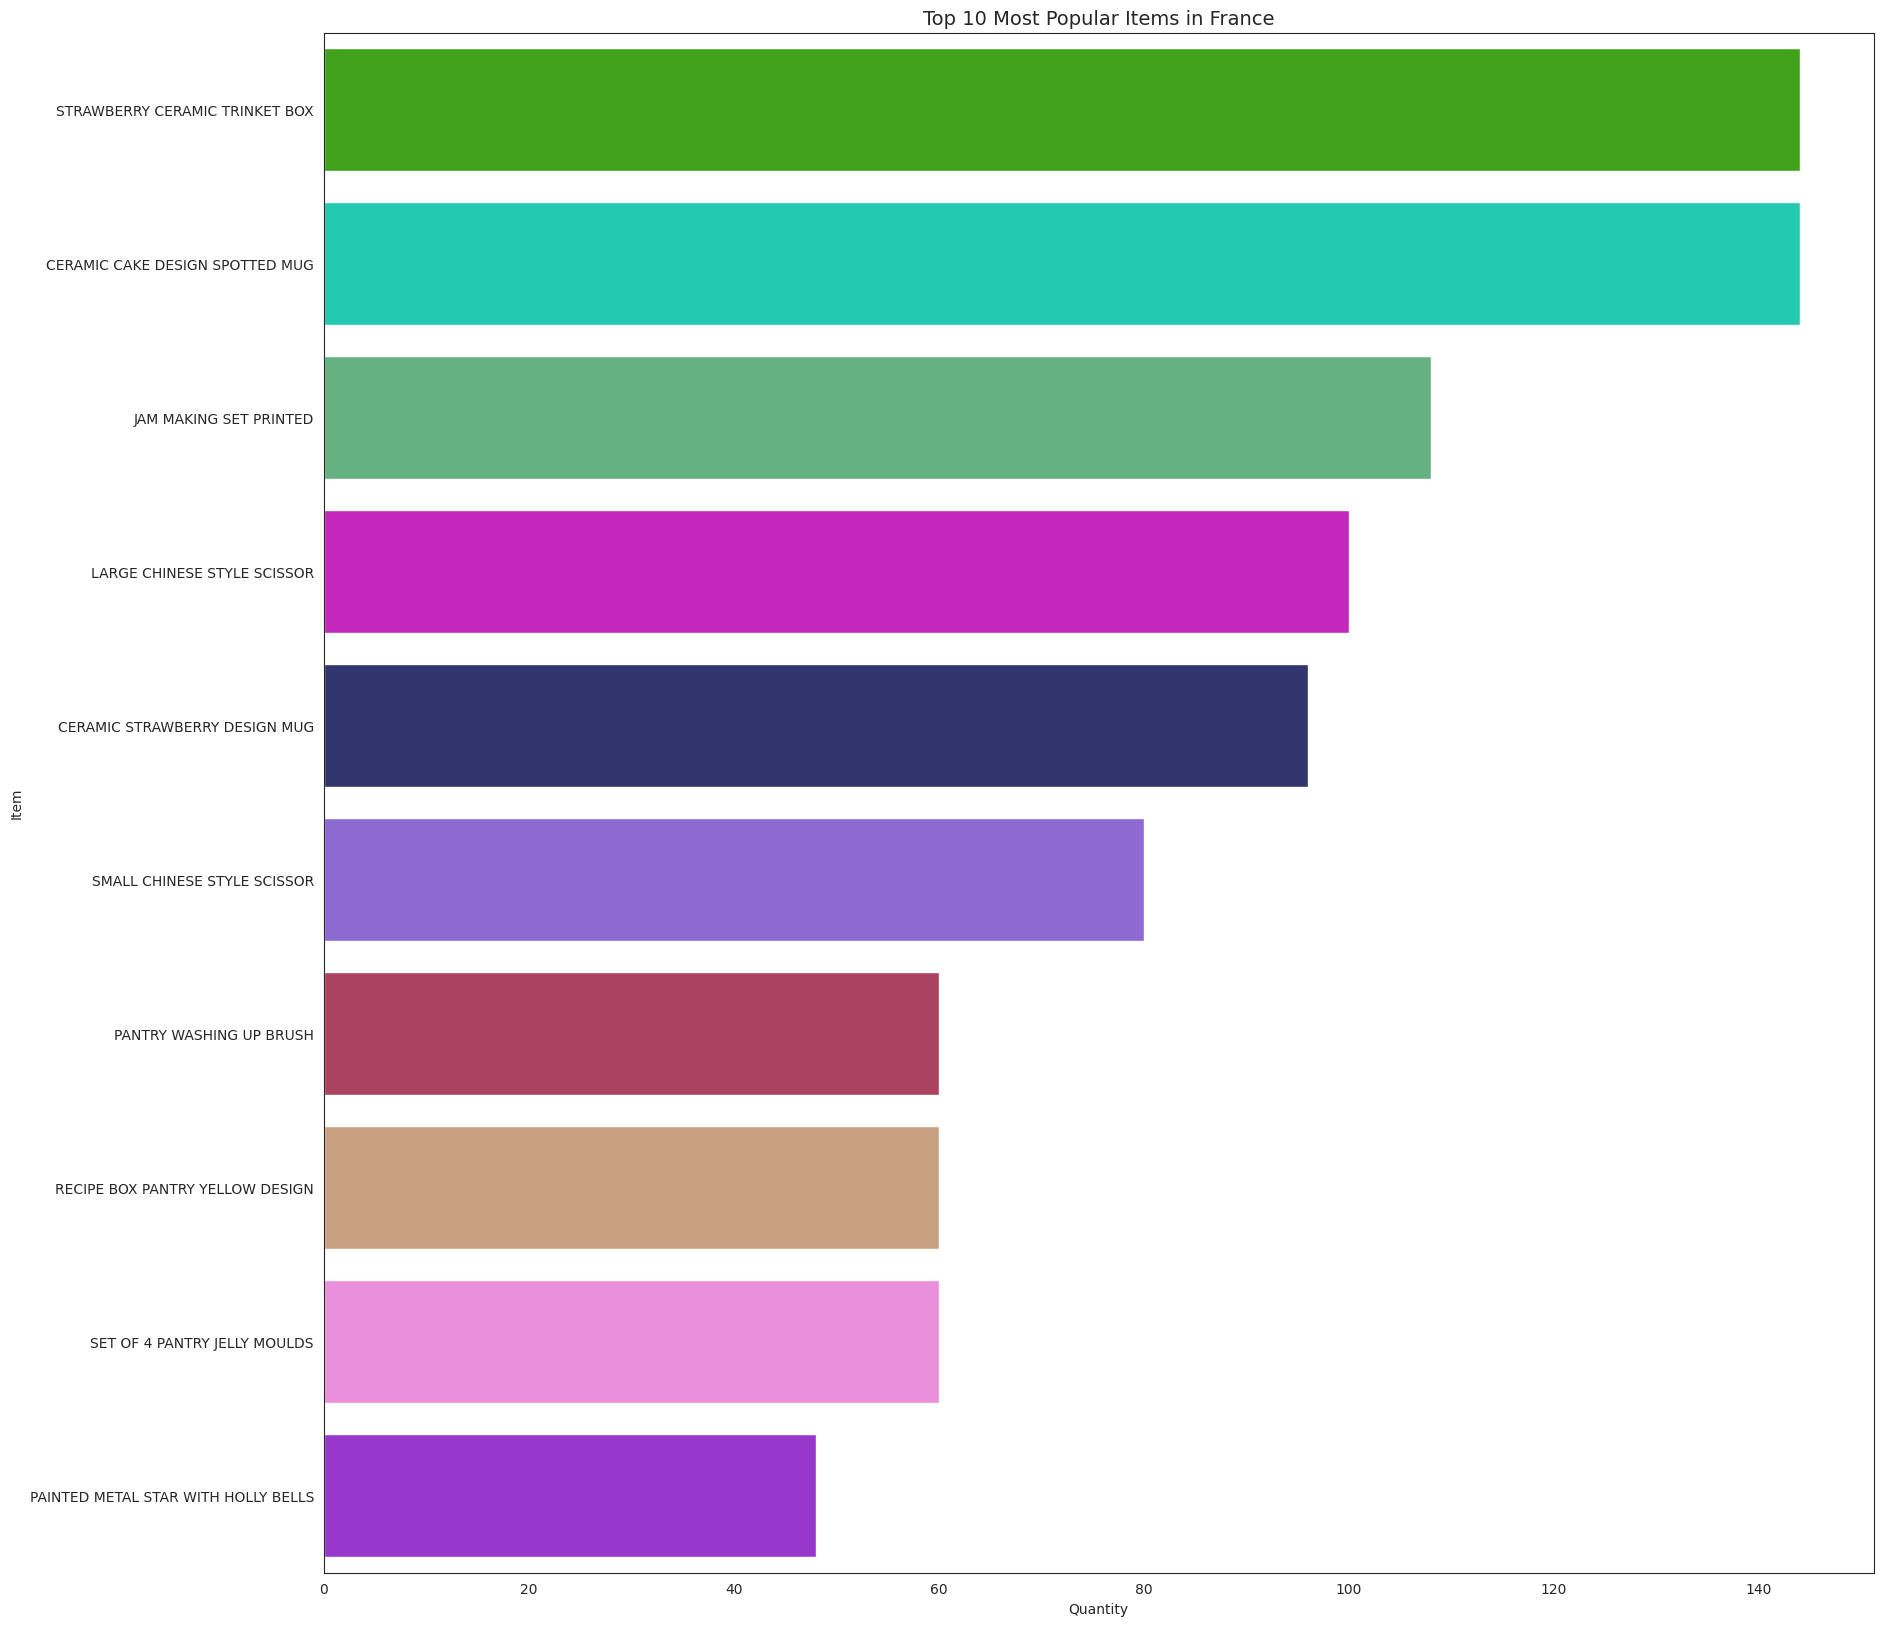

In [25]:
#Viz
sns.barplot(y='Description', x='Quantity',
            data=countrywise[countrywise['Country']=='Poland'].sort_values(
                by='Quantity', ascending=False).head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items in France', fontsize=14)
plt.ylabel('Item')

<ipython-input-26-a6d04bdc473a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',


Text(0, 0.5, 'Item')

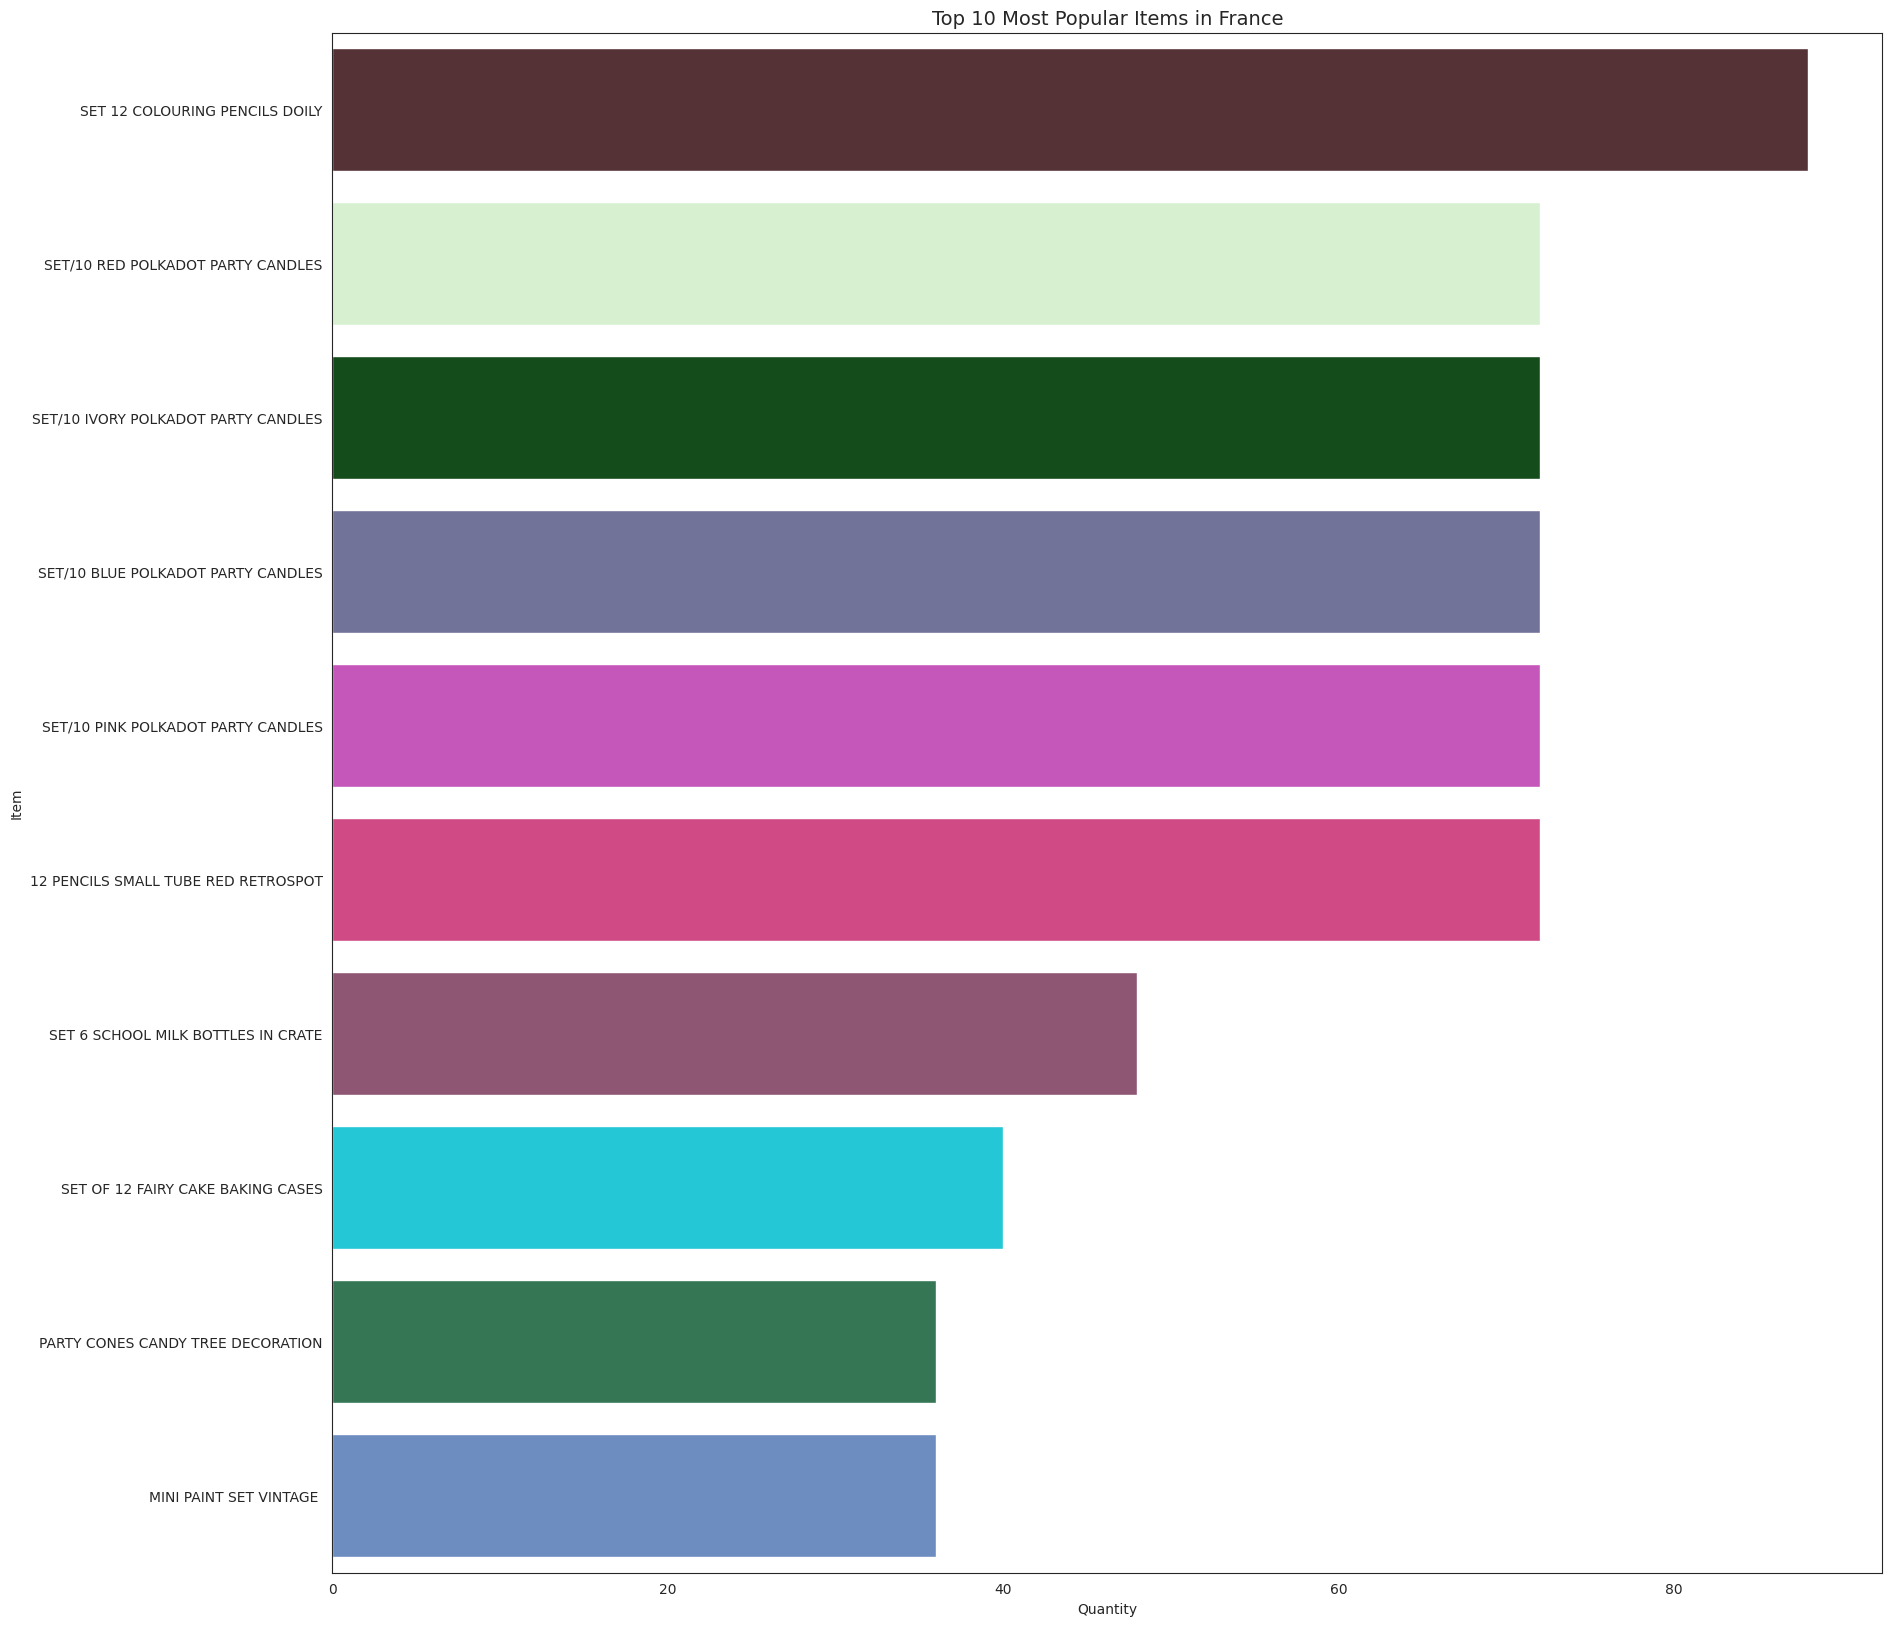

In [26]:
#Viz
sns.barplot(y='Description', x='Quantity',
            data=countrywise[countrywise['Country']=='USA'].sort_values(
                by='Quantity', ascending=False).head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items in France', fontsize=14)
plt.ylabel('Item')

Based on Monthwise Popularity

In [27]:
import datetime
#format datetime
df_new['InvoiceDate'] = pd.to_datetime(df_new.InvoiceDate, format='%Y-%m-%d %H:%M:%S')
df_new.insert(loc=2, column='year_month', value=df_new['InvoiceDate'].map(lambda x: 100*x.year + x.month))
df_new.insert(loc=3, column='month', value=df_new.InvoiceDate.dt.month)
# +1 to make Monday=1.....until Sunday=7
df_new.insert(loc=4, column='day', value=(df_new.InvoiceDate.dt.dayofweek)+1)
df_new.insert(loc=5, column='hour', value=df_new.InvoiceDate.dt.hour)

In [28]:
df_new.head()

,InvoiceNo,StockCode,year_month,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,201012,12,3,8,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,201012,12,3,8,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,201012,12,3,8,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,201012,12,3,8,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,201012,12,3,8,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<ipython-input-29-afff02efcc52>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',


Text(0, 0.5, 'Item')

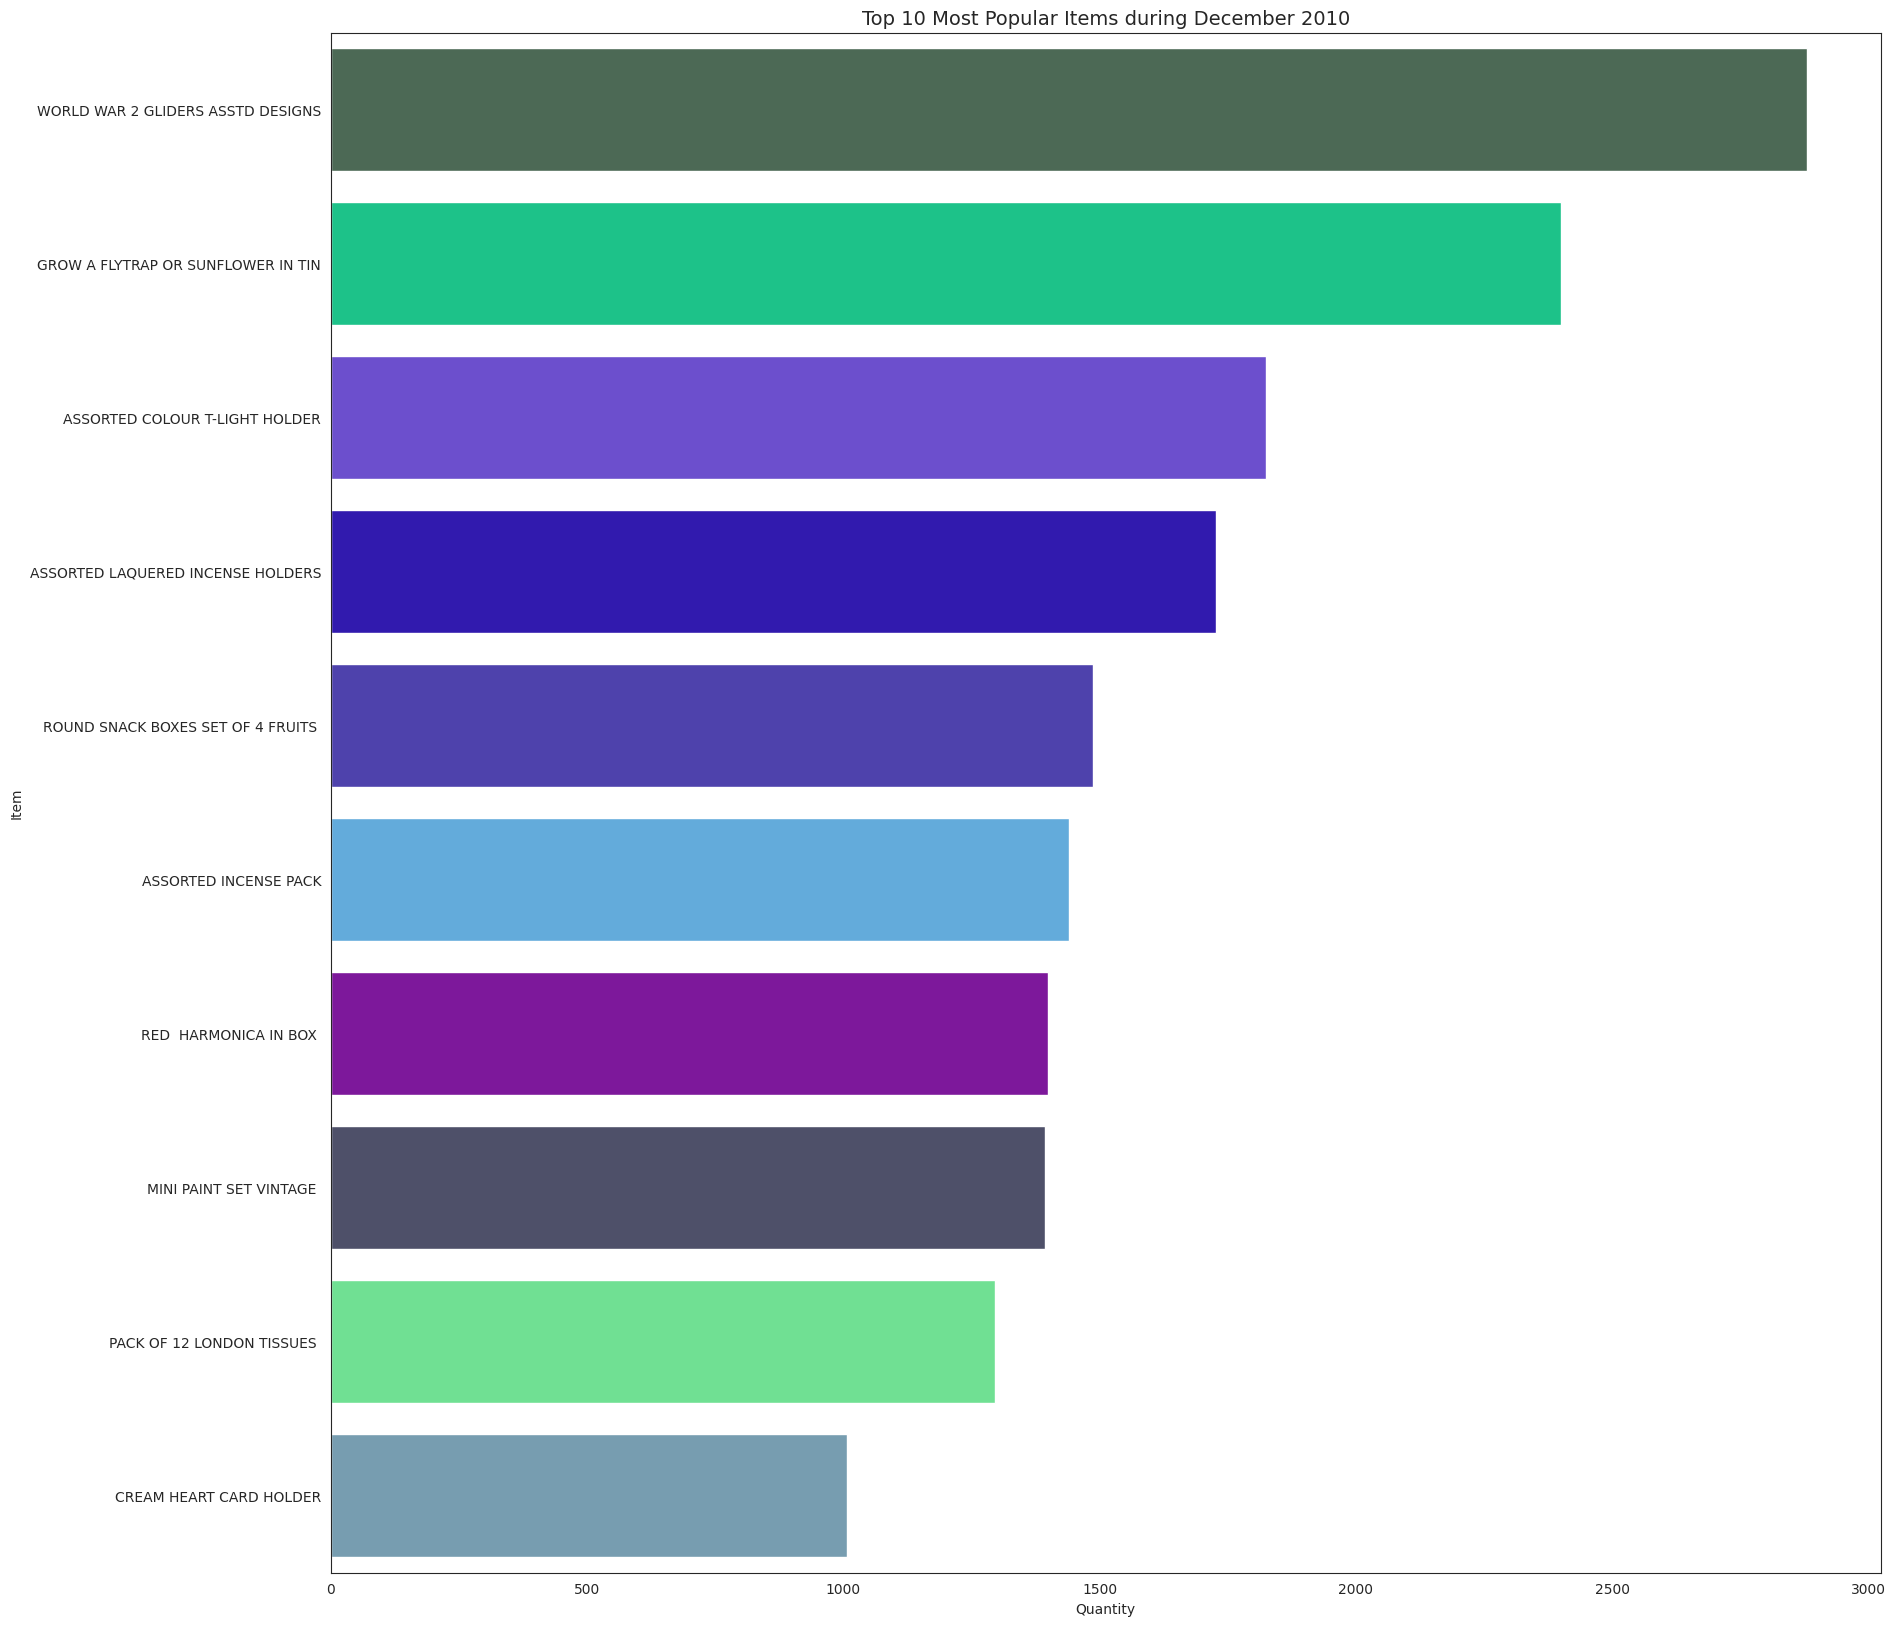

In [29]:
#viz - popular items by month
sns.barplot(y='Description', x='Quantity',
            data=df_new[df_new['year_month']==201012].sort_values(
                by='Quantity', ascending=False).head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items during December 2010', fontsize=14)
plt.ylabel('Item')

<ipython-input-31-de0a4c8ea842>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',
<ipython-input-31-de0a4c8ea842>:2: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.barplot(y='Description', x='Quantity',


Text(0, 0.5, 'Item')

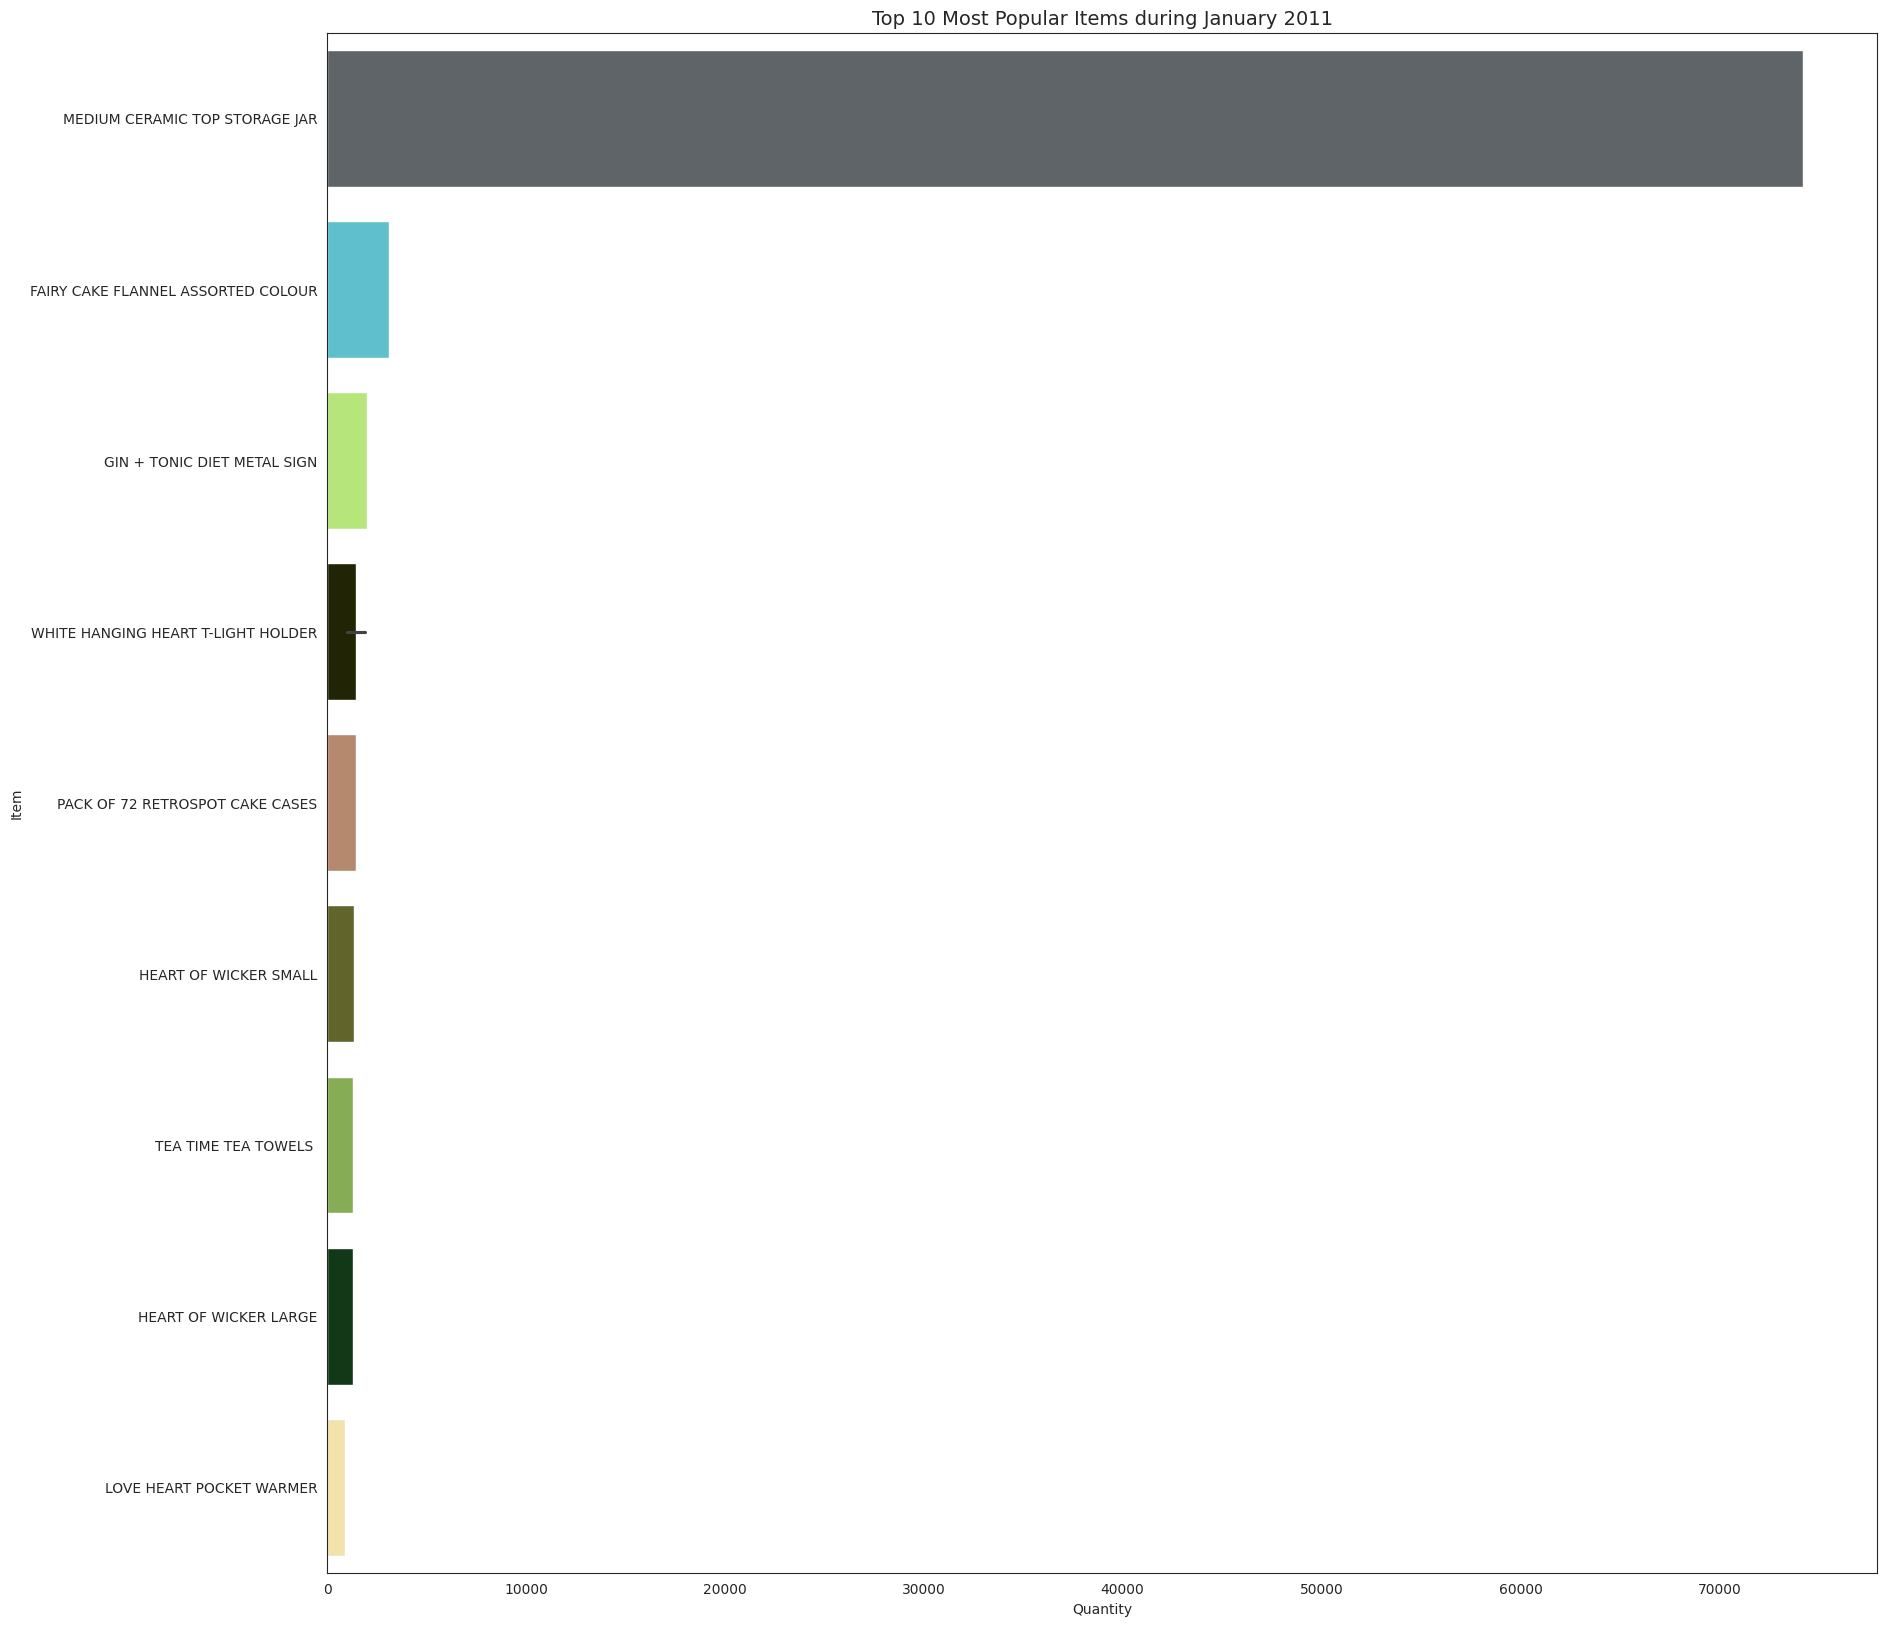

In [31]:
#viz
sns.barplot(y='Description', x='Quantity',
            data=df_new[df_new['year_month']==201101].sort_values(
                by='Quantity', ascending=False).head(10), palette=random_colours(10))
plt.title('Top 10 Most Popular Items during January 2011', fontsize=14)
plt.ylabel('Item')

Repeat Purchase (Buy Again)

In [32]:
df_new['CustomerID'].nunique()

4339

In [33]:
df_new['CustomerID'].value_counts().sample(5)

,count
CustomerID,
12377.0,77
14459.0,37
12955.0,180
15690.0,19
15651.0,32


In [34]:
from collections import Counter

# Extracting all the items bought by customer 12509
desc = df_new[df_new['CustomerID']==12509].Description

# Counting the number of times that purchase has been repeated
count = Counter(desc)

# Counter sorts the items in descending order of purchased count

# Printing the count
print(count)

Counter({'PARTY BUNTING': 1, 'TEA TIME PARTY BUNTING': 1, 'CHARLOTTE BAG PINK POLKADOT': 1, 'CHARLOTTE BAG SUKI DESIGN': 1, 'STRAWBERRY CHARLOTTE BAG': 1, 'SET 7 BABUSHKA NESTING BOXES': 1, 'POSTAGE': 1})


In [35]:
def buy_again(customerid):

    # Fetching the items bought by the customer for provided customer id
    items_bought = df_new[df_new['CustomerID']==customerid].Description

    # Count and sort the repeated purchases
    bought_again = Counter(items_bought)

    # Convert counter to list for printing recommendations
    buy_again_list = list(bought_again)

    # Printing the recommendations
    print('Items you would like to buy again :')
    return(buy_again_list)

In [36]:
buy_again(12509)

Items you would like to buy again :


['PARTY BUNTING',
 'TEA TIME PARTY BUNTING',
 'CHARLOTTE BAG PINK POLKADOT',
 'CHARLOTTE BAG SUKI DESIGN',
 'STRAWBERRY CHARLOTTE BAG',
 'SET 7 BABUSHKA NESTING BOXES',
 'POSTAGE']

In [37]:
buy_again(13419)

Items you would like to buy again :


['WRAP BILLBOARD FONTS DESIGN',
 'CARD BILLBOARD FONT',
 'FANCY FONT BIRTHDAY CARD, ',
 'FANCY FONTS BIRTHDAY WRAP',
 'SET OF 3 NOTEBOOKS IN PARCEL',
 'GIN & TONIC DIET GREETING CARD ',
 'WRAP ENGLISH ROSE ',
 'JUMBO  BAG BAROQUE BLACK WHITE',
 'JUMBO BAG RED RETROSPOT',
 'PACK OF 12 PINK PAISLEY TISSUES ',
 'PACK OF 12 PINK POLKADOT TISSUES',
 'PACK OF 12 RED RETROSPOT TISSUES ',
 'PACK OF 12 HEARTS DESIGN TISSUES ',
 'HAND WARMER BIRD DESIGN',
 'HAND WARMER RED RETROSPOT',
 'HAND WARMER SCOTTY DOG DESIGN']

Products with Most Sales

In [38]:
# Creating a new feature 'Amount' which is the product of Quantity and its Unit Price
df1 = df_new.copy()
df1['Sales'] = df1['Quantity'] * df1['UnitPrice']

In [39]:
cash_cows =df1.pivot_table(
    index=['StockCode','Description'],
    values='Sales',
    aggfunc='sum').sort_values(
    by='Sales', ascending=False)
print('Top 10 sales generating items globally....')
cash_cows.head(10)

Top 10 sales generating items globally....


,,Sales
StockCode,Description,
DOT,DOTCOM POSTAGE,206248.77
22423,REGENCY CAKESTAND 3 TIER,174484.74
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104340.29
47566,PARTY BUNTING,99504.33
85099B,JUMBO BAG RED RETROSPOT,94340.05
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
M,Manual,78110.27
POST,POSTAGE,78101.88


<ipython-input-41-d7c468511346>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Sales', data=cash_cows.head(10), palette=random_colours(10))


Text(0, 0.5, 'Item')

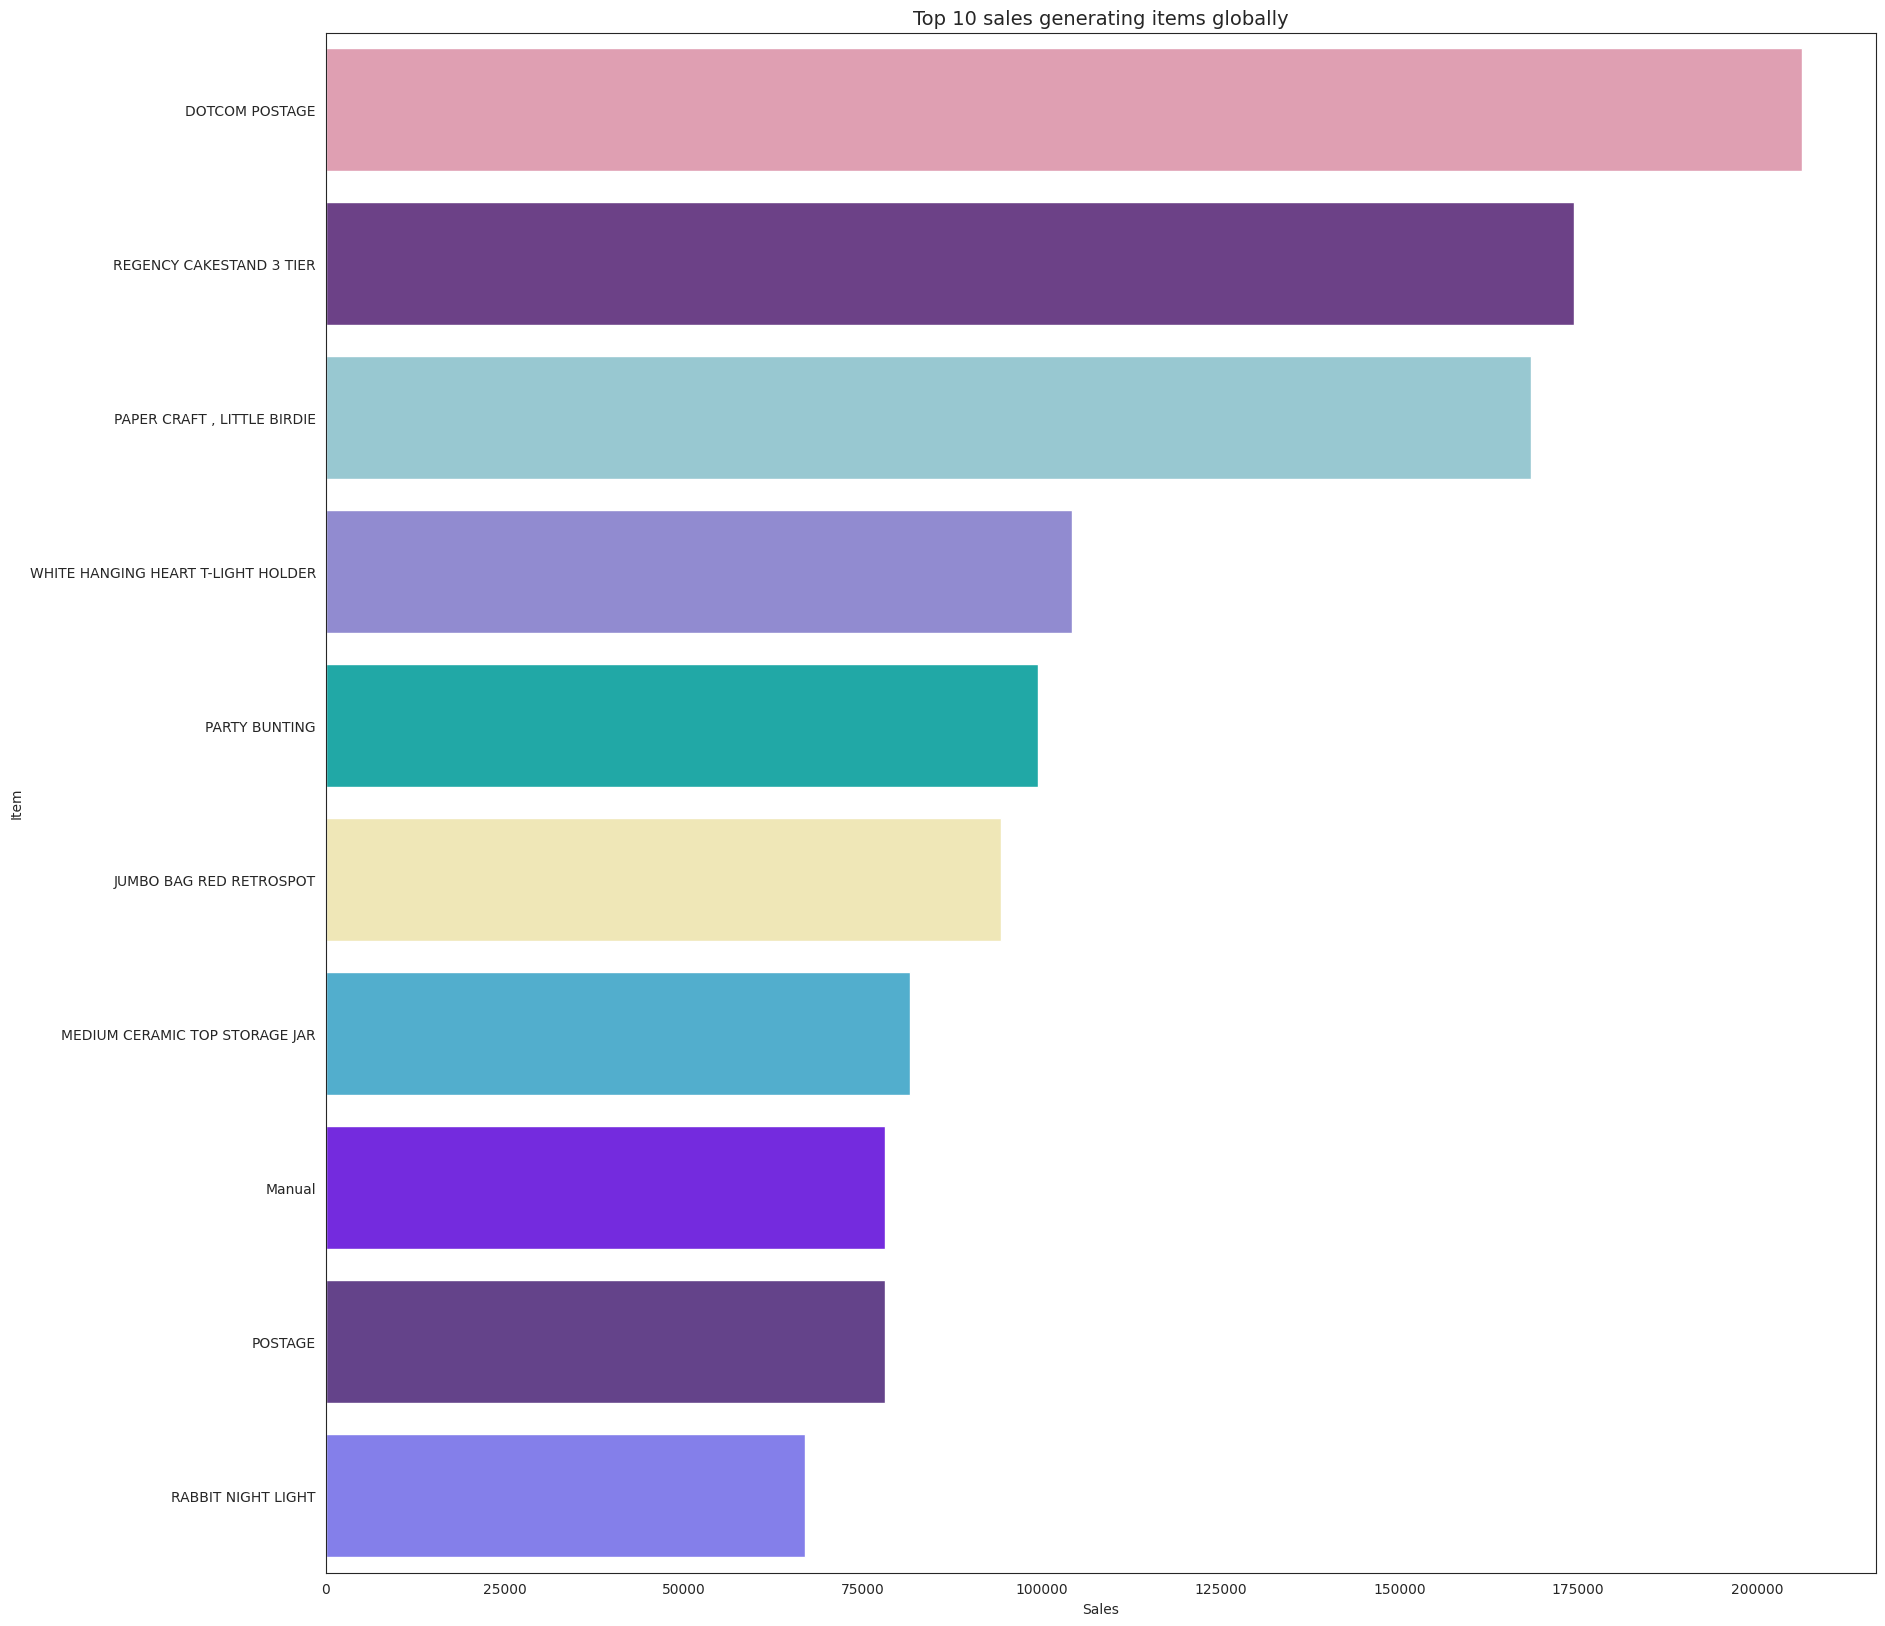

In [41]:
#viz - top products by sales
cash_cows.reset_index(inplace=True)
sns.barplot(y='Description', x='Sales', data=cash_cows.head(10), palette=random_colours(10))
plt.title('Top 10 sales generating items globally', fontsize=14)
plt.ylabel('Item')

​Freebies

In [42]:
#Products with UnitPrice = 0 considered as Freebies
FreeItems = df1[df1["UnitPrice"] == 0]
FreeItems["Description"].nunique()

246

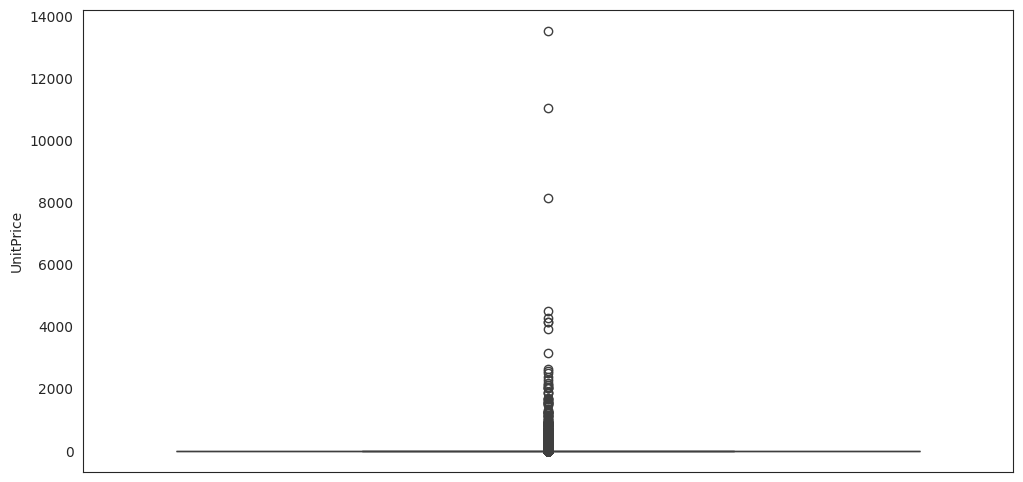

In [43]:
df1 = df1[df1["UnitPrice"]>0]
# checking the distribution of unit price
plt.subplots(figsize=(12,6))

# Using darkgrid style for better visualization
sns.set_style('darkgrid')

# Applying boxplot visualization on Unit Price
sns.boxplot(df1.UnitPrice)

plt.show()

Loyal Customers

In [44]:
# Using groupby function to highlight the Customers with most no. of orders (invoices)

orders = df1.groupby(by=['CustomerID','Country'], as_index=False)['InvoiceNo'].count()

In [45]:
print('The TOP 5 loyal customers with most number of orders...')
orders.sort_values(by='InvoiceNo', ascending=False).head()

The TOP 5 loyal customers with most number of orders...


,CustomerID,Country,InvoiceNo
4018,17841.0,United Kingdom,7847
1887,14911.0,EIRE,5675
1297,14096.0,United Kingdom,5111
334,12748.0,United Kingdom,4595
1669,14606.0,United Kingdom,2700


In [46]:
# Using groupby function to highlight the Customers with highest spent amount (invoices)
money_spent = df1.groupby(by=['CustomerID','Country'], as_index=False)['Sales'].sum()

print('The TOP 5 profitable customers with highest money spent...')
money_spent.sort_values(by='Sales', ascending=False).head()

The TOP 5 profitable customers with highest money spent...


,CustomerID,Country,Sales
1697,14646.0,Netherlands,280206.02
4209,18102.0,United Kingdom,259657.30
3736,17450.0,United Kingdom,194550.79
3016,16446.0,United Kingdom,168472.50
1887,14911.0,EIRE,143825.06


Orders Placed by Number Of Unique customers

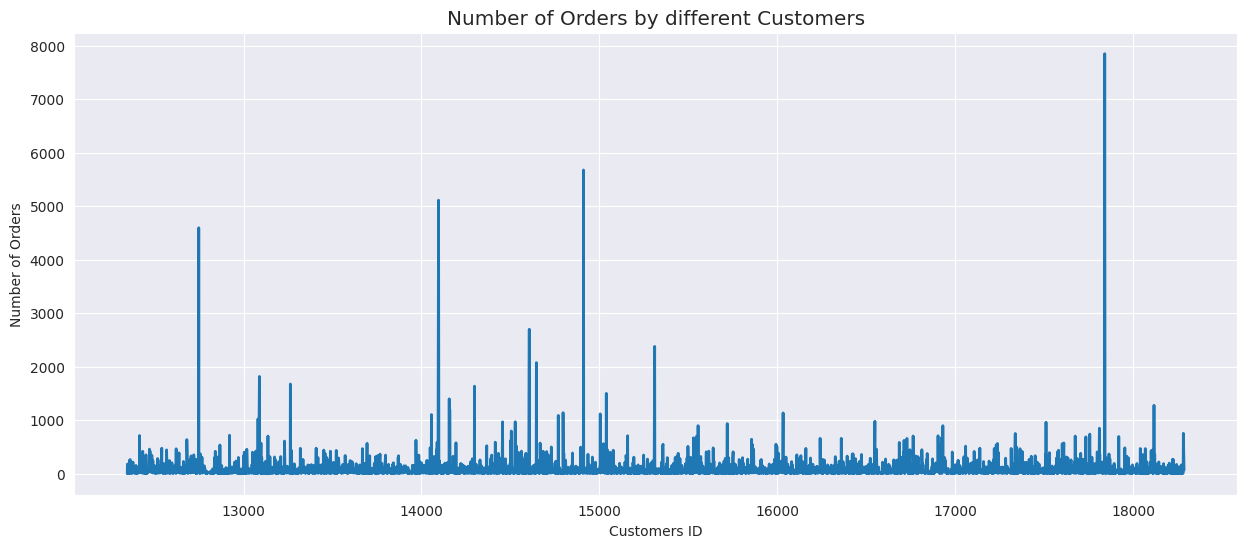

In [47]:
# Creating a subplot of size 15x6
plt.subplots(figsize=(15,6))

# Using the style bmh for better visualization
plt.style.use('bmh')

# X axis will denote the customer ID, Y axis will denote the number of orders
plt.plot(orders.CustomerID, orders.InvoiceNo)

# Labelling the X axis
plt.xlabel('Customers ID')

# Labelling the Y axis
plt.ylabel('Number of Orders')

# Giving a suitable title to the plot
plt.title('Number of Orders by different Customers')

plt.show()

Big Money Spending Customers

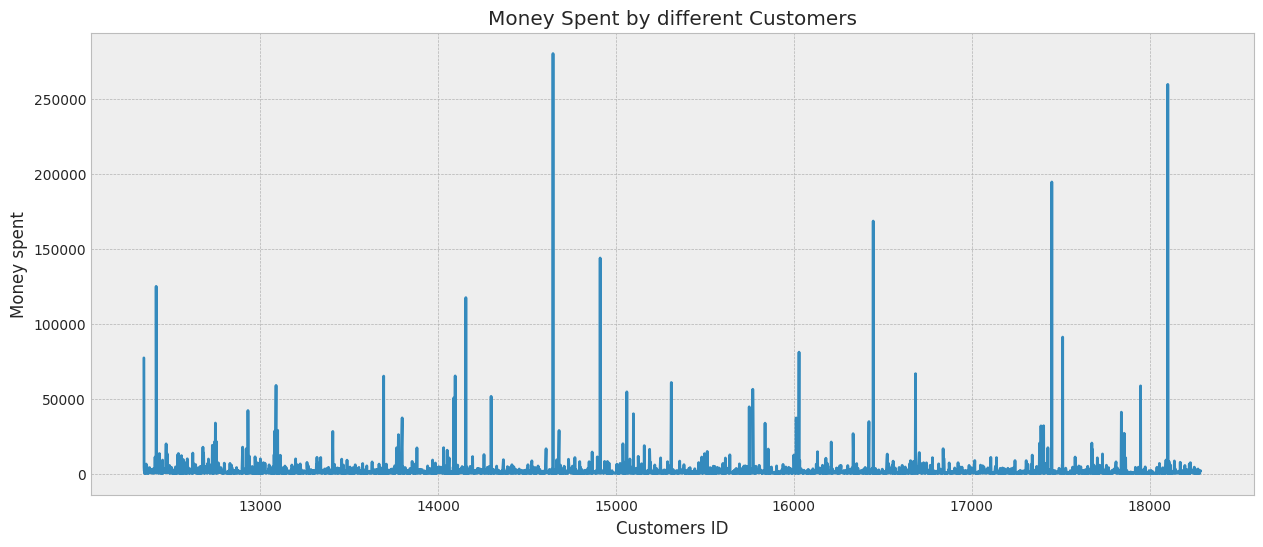

In [48]:
# Creating a subplot of size 15*6
plt.subplots(figsize=(15,6))

# X axis will denote the customer ID, Y axis will denote the amount spent
plt.plot(money_spent.CustomerID, money_spent.Sales)

# Using bmh style for better visualization
plt.style.use('bmh')

# Labelling the X-axis
plt.xlabel('Customers ID')

# Labelling the Y-axis
plt.ylabel('Money spent')

# Giving a suitable title to the plot
plt.title('Money Spent by different Customers')

plt.show()

Orders placed per month

In [50]:
df1.head()

,InvoiceNo,StockCode,year_month,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,201012,12,3,8,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,201012,12,3,8,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,201012,12,3,8,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,201012,12,3,8,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,201012,12,3,8,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [51]:
df1['year_month'].value_counts().sort_index()

,count
year_month,
201012,41480
201101,34306
201102,27105
201103,35803
201104,29096
201105,36164
201106,35977
201107,38645
201108,34483


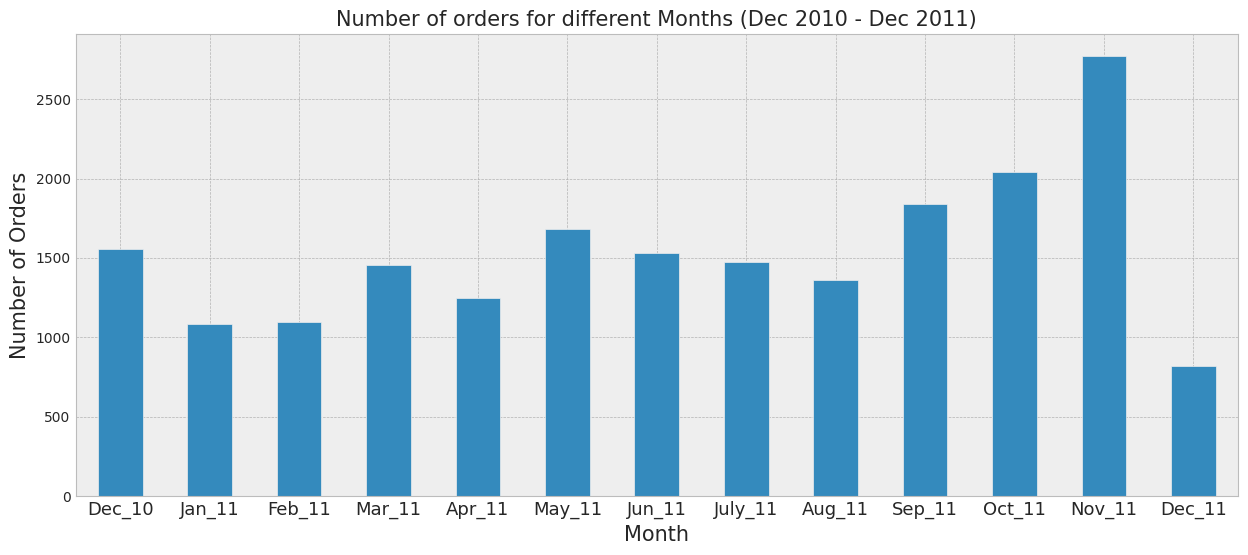

In [49]:
# Using bmh style for better visualization
plt.style.use('bmh')

# Using groupby to extract No. of Invoices year-monthwise
ax = df1.groupby('InvoiceNo')['year_month'].unique().value_counts().sort_index().plot(kind='bar',figsize=(15,6))

# Labelling the X axis
ax.set_xlabel('Month',fontsize=15)

# Labelling the Y-axis
ax.set_ylabel('Number of Orders',fontsize=15)

# Giving suitable title to the plot
ax.set_title('Number of orders for different Months (Dec 2010 - Dec 2011)',fontsize=15)

# Providing with X tick labels
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'), rotation='horizontal', fontsize=13)

plt.show()

Orders placed per Day

In [52]:
df1['day'].value_counts()

,count
day,
4,101007
2,99460
1,93136
3,92315
5,80281
7,63905


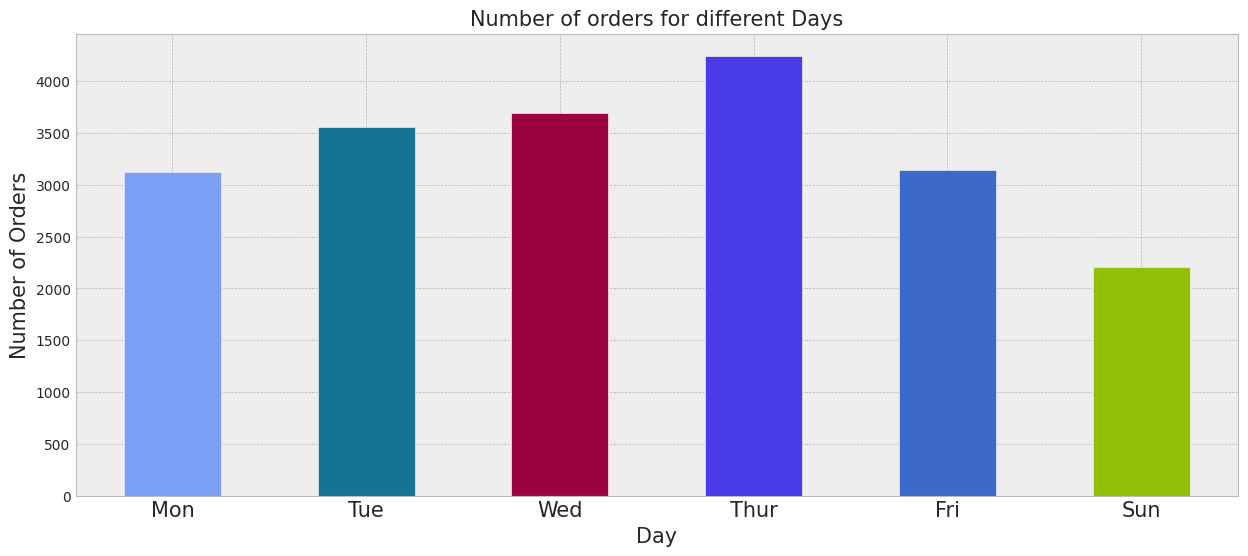

In [55]:
# Using groupby to count no. of Invoices daywise
ax = df1.groupby('InvoiceNo')['day'].unique().value_counts().sort_index().plot(kind='bar',figsize=(15,6), color=random_colours(10))

# Labelling X axis
ax.set_xlabel('Day',fontsize=15)

# Labelling Y axis
ax.set_ylabel('Number of Orders',fontsize=15)

# Giving suitable title to the plot
ax.set_title('Number of orders for different Days',fontsize=15)

# Providing with X tick labels
ax.set_xticklabels(('Mon','Tue','Wed','Thur','Fri','Sun'), rotation='horizontal', fontsize=15)

plt.show()

No Orders were placed on Saturday

Orders placed per Hour?

In [56]:
df1['hour'].unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  7, 18, 19, 20,  6],
      dtype=int32)

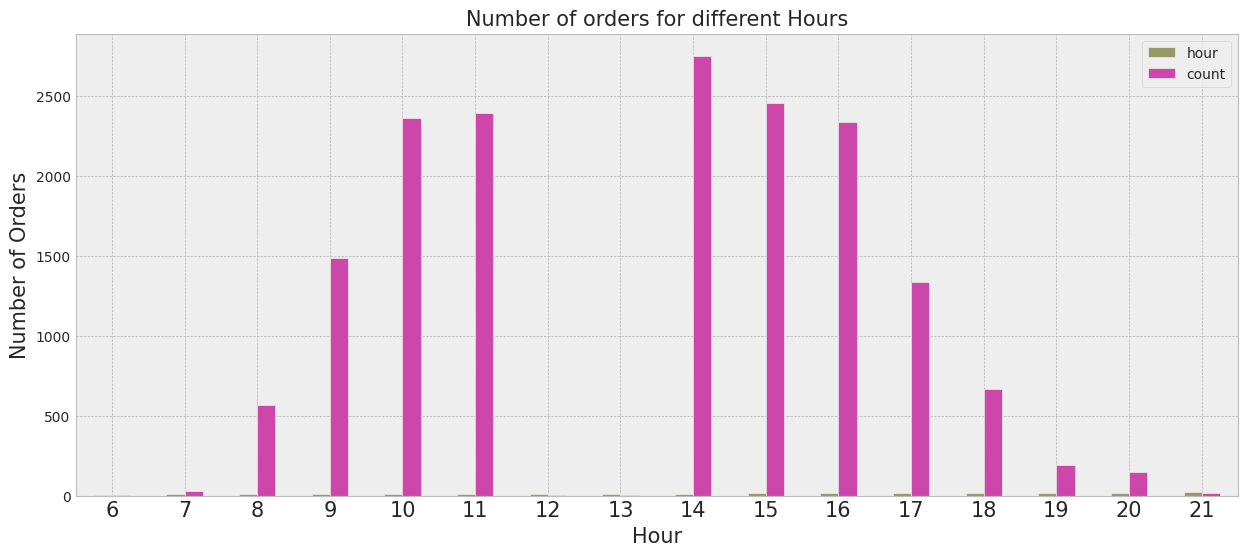

In [61]:
# Using groupby to count the no. of Invoices hourwise
grouped_data = df1.groupby(['InvoiceNo'])['hour'].unique().value_counts()
grouped_data = pd.DataFrame(grouped_data).reset_index() # Reset index to convert 'hour' to a regular column
grouped_data = grouped_data.rename(columns={grouped_data.columns[0]: 'hour', grouped_data.columns[1]: 'count'}) # Rename columns for clarity

# Explode the 'hour' column to have individual hours in separate rows
grouped_data = grouped_data.explode('hour')

# Now, plot the data
ax = grouped_data.iloc[1:].sort_values(by="hour").plot(kind='bar',figsize=(15,6), color=random_colours(len(grouped_data.iloc[1:])))
# Labelling X axis
ax.set_xlabel('Hour',fontsize=15)

# Labelling Y axis
ax.set_ylabel('Number of Orders',fontsize=15)

# Giving suitable title to the plot
ax.set_title('Number of orders for different Hours',fontsize=15)

# Providing with X tick lables ( all orders are placed between 6 and 20 hour )
# The original range(6, 21) produced 15 values, causing the error.
# Changed to range(6, 22) to produce 16 values, matching the number of ticks.
ax.set_xticklabels(range(6,22), rotation='horizontal', fontsize=15)
plt.show()

Trending Products

In [62]:
# Invoice Date is in the form datetime(year, month, day, hour, minute, second, milliseconds)
# We are converting it into datetime(year, month, day) to make the input user-fr

df1['date'] = df1['InvoiceDate'].map(lambda x: x.strftime('%y-%m-%d'))
df1['date']

,date
0,10-12-01
1,10-12-01
2,10-12-01
3,10-12-01
4,10-12-01
...,...
541904,11-12-09
541905,11-12-09
541906,11-12-09
541907,11-12-09


In [63]:
datewise_sales = df1.pivot_table(
    index=['date','StockCode','Description'],
    values='Quantity',
    aggfunc='sum').reset_index()

datewise_sales.head()

,date,StockCode,Description,Quantity
0,10-12-01,10002,INFLATABLE POLITICAL GLOBE,60
1,10-12-01,10125,MINI FUNKY DESIGN TAPES,2
2,10-12-01,10133,COLOURING PENCILS BROWN TUBE,5
3,10-12-01,10135,COLOURING PENCILS BROWN TUBE,1
4,10-12-01,11001,ASSTD DESIGN RACING CAR PEN,3


In [66]:
def trending(date):
    sns.barplot(y='Description', x='Quantity',
                data=datewise_sales[datewise_sales['date']==date].sort_values(
                    by='Quantity', ascending=False).head(10), palette=random_colours(10))
    plt.title('Top 10 Most Selling Items on {0}'.format(date), fontsize=14)
    plt.ylabel('Item')

<ipython-input-66-8e6629c4bdf2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Description', x='Quantity',


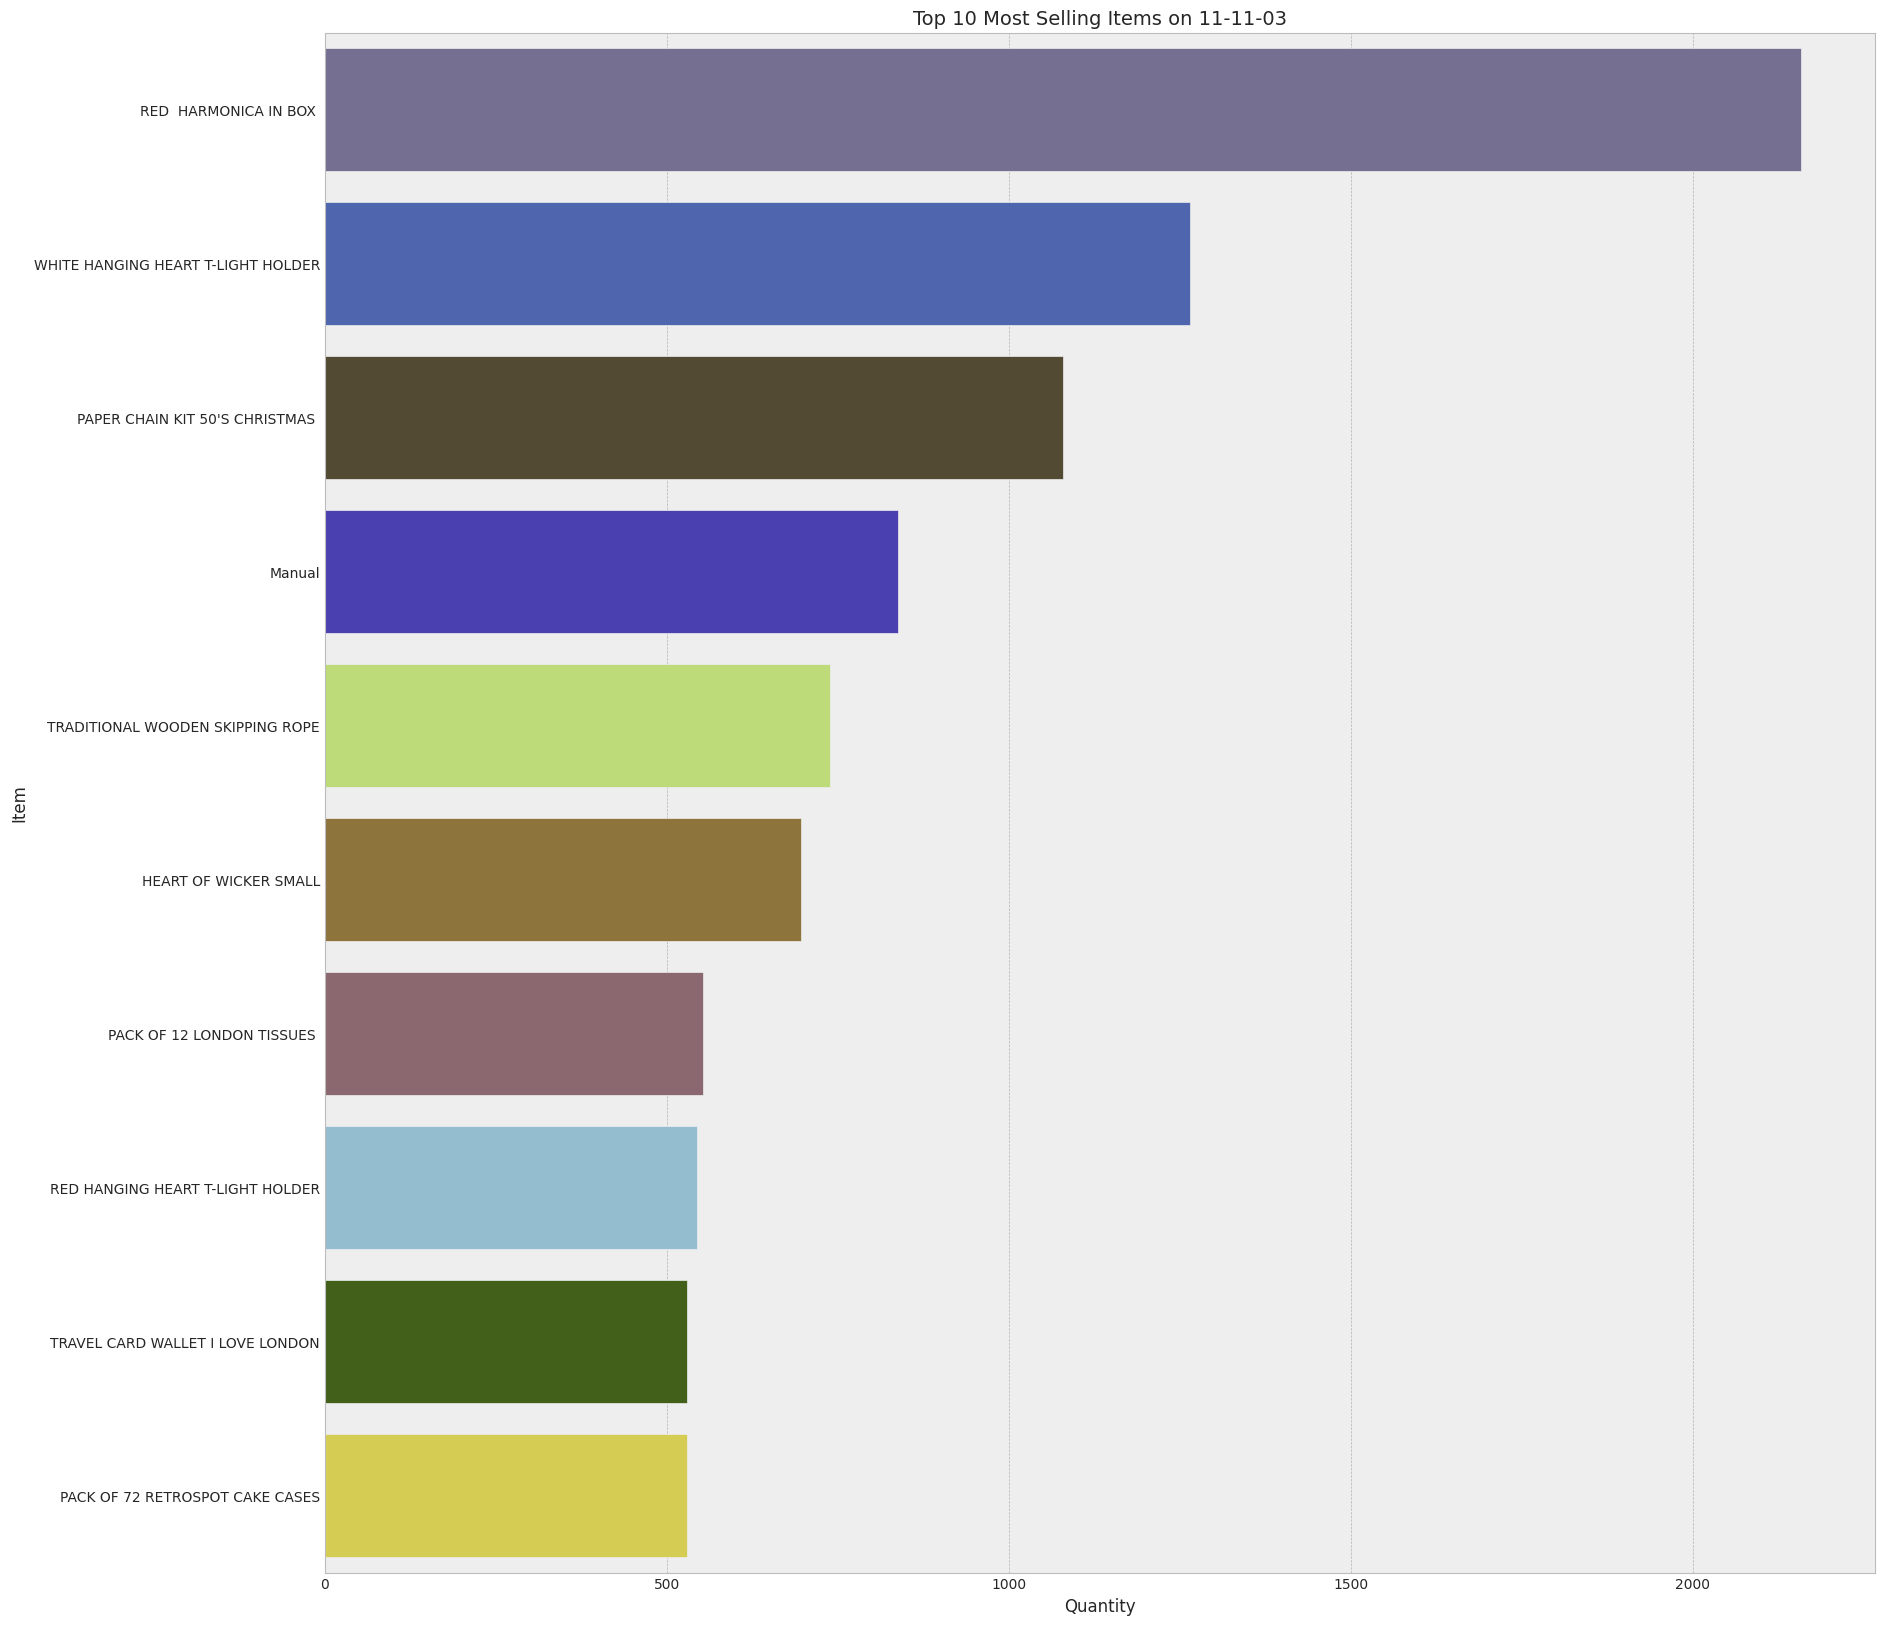

In [67]:
trending("11-11-03")

Hot Deals

The logic for this Deal of the day basket of products differs platform to platform and business to business.

Logic here used is if on a given day a product is not getting sold should climb up in this list and system play on pricing accordingly.

Idea is to churning the inventory for unwanted products as quickly as possible.

In [68]:
def deal_of_the_day(date):

    # sorting the data on given date based on quantity (ascending) by default
    data = datewise_sales[datewise_sales['date']==date].sort_values(by='Quantity')

    print('The most appropriate items to provide Deals on {0} are :'.format(date))
    print(data['Description'].head(10))

In [69]:
deal_of_the_day('11-11-03')

The most appropriate items to provide Deals on 11-11-03 are :
233424         COLOURING PENCILS BROWN TUBE
233425          PAPER POCKET TRAVELING FAN 
234623    PAIR OF PINK FLOWER CLUSTER SLIDE
234622            GOLD DIAMANTE STAR BROOCH
234621             GREEN ENAMEL FLOWER RING
233447          FIRST CLASS PASSPORT COVER 
233453                DOORMAT RED RETROSPOT
233454                      JUMBO BAG TOYS 
234609        DROP DIAMANTE EARRINGS PURPLE
234611     AMBER GLASS/SHELL/PEARL NECKLACE
Name: Description, dtype: object
